In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve

# =============================================================================
# PARÁMETROS Y CONSTANTES
# =============================================================================
# Propiedades del aire (25°C, 1 atm)
rho = 1.184       # Densidad [kg/m³]
mu = 1.849e-5     # Viscosidad dinámica [Pa·s]
nu = mu/rho       # Viscosidad cinemática [m²/s]
k = 0.0262        # Conductividad térmica [W/(m·K)]
alpha = 2.22e-5   # Difusividad térmica [m²/s]
cp = 1006.0       # Calor específico [J/(kg·K)]

# Escalas características
L = 1.0           # Longitud característica [m]
H = 0.1           # Altura característica [m]
u0 = 2.0          # Velocidad característica [m/s]
up = -1.0         # Velocidad placa [m/s]
T0 = 293.0        # Temperatura referencia [K]
p0 = 101325.0     # Presión referencia [Pa]

# Cálculo de u_c, p_f y T_f
uc = u0 - up      # Velocidad característica corregida
pf = mu*uc*L/H**2 + p0
Tf = T0 + (mu*uc**2)/k

# Parámetros adimensionales
Lambda = L/H
Re = rho*u0*L/mu
tc = L/uc
varphi = nu/(L*u0)
beta = alpha*L**3/(u0*H**2)
Eu = (pf-p0)/(rho*u0**2)
delta = mu*u0/(rho*cp*L)

# =============================================================================
# DISCRETIZACIÓN ESPACIAL
# =============================================================================
N_eta = 100       # Puntos en dirección η (x)
N_sigma = 50      # Puntos en dirección σ (y)
eta = np.linspace(0, 1, N_eta)
sigma = np.linspace(0, 1, N_sigma)
dx = eta[1] - eta[0]
dy = sigma[1] - sigma[0]

# Malla
X, Y = np.meshgrid(eta, sigma)

# Discretización temporal

dt = 0.001           # Paso de tiempo
nt = 500             # Número de pasos de tiempo

# Inicialización de variables
u_eta = np.zeros((N_sigma, N_eta))
u_sigma = np.zeros((N_sigma, N_eta))
theta = np.zeros((N_sigma, N_eta))
xi = np.zeros((N_sigma, N_eta))

# Aplicar condiciones de frontera
u_eta[:, 0] = 0     # Placa inferior móvil
u_eta[:, -1] = 1    # Flujo libre superior
theta[:, 0] = 0      # Temperatura de la placa
theta[:, -1] = 0     # Temperatura del fluido lejos de la placa


# EVOLUCIÓN TEMPORAL (ESQUEMA EXPLICITO)

# Definición de funciones:

def d_eta(variable, coordenada1, coordenada2, diferencia):
    
    return (variable[coordenada1 + 1, coordenada2] - variable[coordenada1 - 1, coordenada2]) / (2*diferencia)

def d_sigma(variable, coordenada1, coordenada2, diferencia):
    
    return (variable[coordenada1, coordenada2 + 1] - variable[coordenada1, coordenada2-1]) / (2*diferencia)

def d2_eta(variable, coordenada1, coordenada2, diferencia):

    return (variable[coordenada1 + 1, coordenada2] - 2* variable [coordenada1, coordenada2] + variable[coordenada1 - 1, coordenada2]) / (diferencia**2)


def d2_sigma(variable, coordenada1, coordenada2, diferencia):

    return (variable[coordenada1, coordenada2+1] - 2* variable [coordenada1, coordenada2] + variable[coordenada1, coordenada2 - 1]) / (diferencia**2)


for n in range(nt):
    # Copiar campos anteriores
    u_eta_old = u_eta.copy()
    u_sigma_old = u_sigma.copy()
    theta_old = theta.copy()

    # Resolver Navier-Stokes (simplificado)
    for n in range(1, N_sigma-1):
        for m in range(1, N_eta-1):
            # Ecuación de u (componente x)
            u_eta[m, n] = u_eta_old[m, n] - dt * (u_eta_old[m, n] * d_eta(u_eta_old, m, n, dx) + Lambda * u_sigma_old[m, n] * d_sigma(u_eta_old, m, n, dy) 
                                                + varphi * (d2_eta(u_eta_old, m, n, dx) + Lambda**2 * d2_sigma(u_eta_old, m, n, dy)) )

            # Ecuación de T (temperatura)
            theta[m, n] = theta_old[m, n] + dt * (-(u_eta_old[m, n] * d_eta(theta_old, m, n, dx) + u_sigma_old[m, n] * d_sigma(theta_old, m, n, dy)) + 
                                                  beta * (d2_eta(theta_old, m, n, dx) + Lambda * d2_sigma(theta_old, m, n, dy)) + 
                                                  delta * (2 * (d_eta(u_eta_old, m, n, dx)**2 + Lambda * d_sigma(u_sigma_old, m, n, dy)**2) + 
                                                           (d_eta(u_sigma_old, m, n, dx))*2 + Lambda**2 * d_sigma(u_eta_old, m, n, dy)))

    # Aplicar condiciones de frontera nuevamente
    u_eta[:, 0] = 0
    u_eta[:, -1] = 1
    u_sigma[:, 0] = u_sigma[:, -1] = 0
    theta[:, 0], theta[:, -1] = 0

# Cálculo de la presión mediante ecuación de Poisson (simplificado)
# Usamos una aproximación simple basada en la divergencia del campo de velocidad
max_iter = 500  # Número máximo de iteraciones para el solver de presión
tolerance = 1e-4  # Tolerancia para la convergencia

# Inicialización del campo de presión
p = np.zeros((N_eta, N_sigma))

# Solver iterativo para la presión
for _ in range(max_iter):
    p_old = p.copy()
    
    for n in range(1, N_sigma-1):
        for m in range(1, N_eta-1):
            # Aproximación discreta de la ecuación de Poisson para la presión
            p[m, n] = 0.25 * (p_old[m+1, n] + p_old[m-1, n] + 
                             p_old[m, n+1] + p_old[m, n-1] -
                             (rho * dx**2) * (
                                 (u_eta[m+1, n] - u_eta[m-1, n]) / (2*dx) * (u_sigma[m, n+1] - u_sigma[m, n-1]) / (2*dy) -
                                 ((u_eta[m, n+1] - u_eta[m, n-1]) / (2*dy))**2 -
                                 ((u_sigma[m+1, n] - u_sigma[m-1, n]) / (2*dx))**2
                             ))
    
    # Condiciones de frontera para la presión (Neumann homogéneas)
    p[0, :] = p[1, :]   # Frontera inferior
    p[-1, :] = p[-2, :] # Frontera superior
    p[:, 0] = p[:, 1]   # Frontera izquierda
    p[:, -1] = p[:, -2] # Frontera derecha
    
    # Criterio de convergencia
    if np.max(np.abs(p - p_old)) < tolerance:
        break

# Encontrar los valores máximos y mínimos de presión
p_max = np.max(p)
p_min = np.min(p)
p_max_coords = np.unravel_index(np.argmax(p), p.shape)
p_min_coords = np.unravel_index(np.argmin(p), p.shape)

# Convertir índices a coordenadas físicas
p_max_x, p_max_y = eta[p_max_coords[1]], sigma[p_max_coords[0]]
p_min_x, p_min_y = eta[p_min_coords[1]], sigma[p_min_coords[0]]

print(f"\nPresión máxima: {p_max:.4f} en ({p_max_x:.2f}, {p_max_y:.2f})")
print(f"Presión mínima: {p_min:.4f} en ({p_min_x:.2f}, {p_min_y:.2f})")

# REPRESENTACIÓN GRÁFICA ACTUALIZADA
plt.figure(figsize=(24, 5))

# Gráfico de velocidad
plt.subplot(1, 4, 1)
plt.contourf(X, Y, u_eta, levels=20, cmap='jet')
plt.colorbar(label='Velocidad (u) [m/s]')
plt.title('Campo de Velocidad Horizontal')
plt.xlabel('x'), plt.ylabel('y')

# Gráfico de temperatura
plt.subplot(1, 4, 2)
plt.contourf(X, Y, theta, levels=20, cmap='hot')
plt.colorbar(label='Temperatura (T) [°C]')
plt.title('Distribución de Temperatura')
plt.xlabel('x'), plt.ylabel('y')

# ESFUERZO CORTANTE

# Calcular derivadas para el esfuerzo cortante
dudy = np.gradient(u_eta, dy, axis=0)
dvdx = np.gradient(u_sigma, dx, axis=1)
tau_xy = mu * (dudy + dvdx)

# Gráfico de esfuerzo cortante
plt.subplot(1, 4, 3)
plt.contourf(X, Y, tau_xy, levels=20, cmap='viridis')
plt.colorbar(label='Esfuerzo Cortante (τ_xy) [Pa]')
plt.title('Distribución del Esfuerzo Cortante')
plt.xlabel('x'), plt.ylabel('y')

# Nuevo gráfico de presión
plt.subplot(1, 4, 4)
pressure_plot = plt.contourf(X, Y, p, levels=20, cmap='coolwarm')
plt.colorbar(label='Presión (p) [Pa]')
plt.title('Distribución de Presión')
plt.xlabel('x'), plt.ylabel('y')

# Añadir marcadores para máximos/mínimos
plt.scatter(p_max_x, p_max_y, c='red', label=f'Max: {p_max:.2f} Pa')
plt.scatter(p_min_x, p_min_y, c='blue', label=f'Min: {p_min:.2f} Pa')
plt.legend()

plt.tight_layout()
plt.show()



IndexError: index 50 is out of bounds for axis 0 with size 50

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# =============================================================================
# PARÁMETROS Y CONSTANTES
# =============================================================================
# Propiedades del aire (25°C, 1 atm)
rho = 1.184       # Densidad [kg/m³]
mu = 1.849e-5     # Viscosidad dinámica [Pa·s]
nu = mu/rho       # Viscosidad cinemática [m²/s]
k = 0.0262        # Conductividad térmica [W/(m·K)]
alpha = 2.22e-5   # Difusividad térmica [m²/s]
cp = 1006.0       # Calor específico [J/(kg·K)]

# Escalas características
L = 1.0           # Longitud característica [m]
H = 0.1           # Altura característica [m]
u0 = 2.0          # Velocidad característica [m/s]
up = -1.0         # Velocidad placa [m/s]
T0 = 293.0        # Temperatura referencia [K]
p0 = 101325.0     # Presión referencia [Pa]

# Cálculo de u_c, p_f y T_f
uc = u0 - up      # Velocidad característica corregida
pf = mu*uc*L/H**2 + p0
Tf = T0 + (mu*uc**2)/k

# Parámetros adimensionales
Lambda = L/H
Re = rho*u0*L/mu
tc = L/uc
varphi = nu/(L*u0)
beta = alpha*L**3/(u0*H**2)
Eu = (pf-p0)/(rho*u0**2)
delta = mu*u0/(rho*cp*L)

# =============================================================================
# DISCRETIZACIÓN ESPACIAL
# =============================================================================
N_eta = 100       # Puntos en dirección η (x)
N_sigma = 50      # Puntos en dirección σ (y)
eta = np.linspace(0, 1, N_eta)
sigma = np.linspace(0, 1, N_sigma)
dx = eta[1] - eta[0]
dy = sigma[1] - sigma[0]

# Malla
X, Y = np.meshgrid(eta, sigma)

# Discretización temporal

dt = 0.001           # Paso de tiempo
nt = 500             # Número de pasos de tiempo

# Inicialización de variables
u_eta = np.zeros((N_sigma, N_eta))
u_sigma = np.zeros((N_sigma, N_eta))
theta = np.zeros((N_sigma, N_eta))
xi = np.zeros((N_sigma, N_eta))

# Aplicar condiciones de frontera
u_eta[:, 0] = 0     # Placa inferior móvil
u_eta[:, -1] = 1    # Flujo libre superior
theta[:, 0] = 0      # Temperatura de la placa
theta[:, -1] = 0     # Temperatura del fluido lejos de la placa


# EVOLUCIÓN TEMPORAL (ESQUEMA EXPLICITO)

# Definición de funciones:

def d_eta(variable, coordenada1, coordenada2, diferencia):
    
    return (variable[coordenada1 + 1, coordenada2] - variable[coordenada1 - 1, coordenada2]) / (2*diferencia)

def d_sigma(variable, coordenada1, coordenada2, diferencia):
    
    return (variable[coordenada1, coordenada2 + 1] - variable[coordenada1, coordenada2-1]) / (2*diferencia)

def d2_eta(variable, coordenada1, coordenada2, diferencia):

    return (variable[coordenada1 + 1, coordenada2] - 2* variable [coordenada1, coordenada2] + variable[coordenada1 - 1, coordenada2]) / (diferencia**2)


def d2_sigma(variable, coordenada1, coordenada2, diferencia):

    return (variable[coordenada1, coordenada2+1] - 2* variable [coordenada1, coordenada2] + variable[coordenada1, coordenada2 - 1]) / (diferencia**2)


for n in range(nt):
    # Copiar campos anteriores
    u_eta_old = u_eta.copy()
    u_sigma_old = u_sigma.copy()
    theta_old = theta.copy()

    # Resolver Navier-Stokes (simplificado)
    for n in range(1, N_sigma-1):
        for m in range(1, N_eta-1):
            # Ecuación de u (componente x)
            u_eta[m, n] = u_eta_old[m, n] - dt * (u_eta_old[m, n] * d_eta(u_eta_old, m, n, dx) + Lambda * u_sigma_old[m, n] * d_sigma(u_eta_old, m, n, dy) 
                                                + varphi * (d2_eta(u_eta_old, m, n, dx) + Lambda**2 * d2_sigma(u_eta_old, m, n, dy)) )

            # Ecuación de T (temperatura)
            theta[m, n] = theta_old[m, n] + dt * (-(u_eta_old[m, n] * d_eta(theta_old, m, n, dx) + u_sigma_old[m, n] * d_sigma(theta_old, m, n, dy)) + 
                                                  beta * (d2_eta(theta_old, m, n, dx) + Lambda * d2_sigma(theta_old, m, n, dy)) + 
                                                  delta * (2 * (d_eta(u_eta_old, m, n, dx)**2 + Lambda * d_sigma(u_sigma_old, m, n, dy)**2) + 
                                                           (d_eta(u_sigma_old, m, n, dx))*2 + Lambda**2 * d_sigma(u_eta_old, m, n, dy)))

    # Aplicar condiciones de frontera nuevamente
    u_eta[:, 0] = 0
    u_eta[:, -1] = 1
    u_sigma[:, 0] = u_sigma[:, -1] = 0
    theta[:, 0], theta[:, -1] = 0


# 1. Método SIMPLE para presión-velocidad
def solve_pressure_SIMPLE(u_eta, u_sigma, dx, dy, rho, N_sigma, N_eta, max_iter=100, tol=1e-4):
    """
    Resuelve la ecuación de presión usando el algoritmo SIMPLE
    """
    # Inicializar presión y campos de corrección
    p = np.zeros((N_sigma, N_eta))
    p_corr = np.zeros((N_sigma, N_eta))
    u_eta_corr = np.zeros_like(u_eta)
    u_sigma_corr = np.zeros_like(u_sigma)
    
    for iter in range(max_iter):
        # Paso 1: Resolver ecuaciones de momento
        # [Aquí iría la solución de las ecuaciones de momento]
        
        # Paso 2: Calcular términos fuente para presión
        S = np.zeros((N_sigma, N_eta))
        for i in range(1, N_sigma-1):
            for j in range(1, N_eta-1):
                S[i,j] = rho * ((u_eta[i,j+1] - u_eta[i,j-1])/(2*dx) + 
                          (u_sigma[i+1,j] - u_sigma[i-1,j])/(2*dy))
        
        # Paso 3: Resolver ecuación de Poisson para corrección de presión
        # Usando scipy.sparse para mejor eficiencia
        A = build_pressure_matrix(N_sigma, N_eta, dx, dy)
        p_corr_flat = spsolve(A, -S.flatten())
        p_corr = p_corr_flat.reshape((N_sigma, N_eta))
        
        # Paso 4: Corregir presión y velocidades
        p += 0.1 * p_corr  # Sub-relajación típica
        
        # Corregir velocidades
        for i in range(1, N_sigma-1):
            for j in range(1, N_eta-1):
                u_eta_corr[i,j] = -dy * (p_corr[i,j+1] - p_corr[i,j-1])/(2*rho*dx)
                u_sigma_corr[i,j] = -dx * (p_corr[i+1,j] - p_corr[i-1,j])/(2*rho*dy)
        
        u_eta += u_eta_corr
        u_sigma += u_sigma_corr
        
        # Verificar convergencia
        if np.max(np.abs(p_corr)) < tol:
            break
    
    return p

def build_pressure_matrix(N_sigma, N_eta, dx, dy):
    """
    Construye matriz para ecuación de Poisson usando diferencias finitas
    """
    N = N_sigma * N_eta
    diagonals = np.zeros((5, N))
    
    # Coeficientes para puntos internos
    for i in range(1, N_sigma-1):
        for j in range(1, N_eta-1):
            idx = i*N_eta + j
            diagonals[0, idx] = -2/(dx**2) - 2/(dy**2)  # Centro
            diagonals[1, idx] = 1/(dy**2)  # Norte (i+1)
            diagonals[2, idx] = 1/(dx**2)  # Este (j+1)
            diagonals[3, idx] = 1/(dy**2)  # Sur (i-1)
            diagonals[4, idx] = 1/(dx**2)  # Oeste (j-1)
    
    # Condiciones de frontera Neumann (dp/dn = 0)
    # [Implementar según necesidades]
    
    A = diags(diagonals, [0, N_eta, 1, -N_eta, -1], shape=(N, N), format='csr')
    return A

# 2. Condiciones de frontera mejoradas
def apply_boundary_conditions(u_eta, u_sigma, p, theta, N_sigma, N_eta):
    # Placa inferior móvil (Condición de no-deslizamiento)
    u_eta[0, :] = 0  # No deslizamiento
    u_sigma[0, :] = 0  # Impermeable
    
    # Flujo libre superior (Condición de deslizamiento)
    u_eta[-1, :] = 1  # Velocidad libre
    u_sigma[-1, :] = 0  # Impermeable
    
    # Condiciones laterales (periódicas para este caso)
    u_eta[:, 0] = u_eta[:, -2]  # Periodicidad
    u_eta[:, -1] = u_eta[:, 1]
    u_sigma[:, 0] = u_sigma[:, -2]
    u_sigma[:, -1] = u_sigma[:, 1]
    
    # Temperatura (Dirichlet)
    theta[0, :] = 0  # Placa fría
    theta[-1, :] = 0  # Flujo libre
    
    # Presión (Neumann)
    p[0, :] = p[1, :]  # Frontera inferior
    p[-1, :] = p[-2, :]  # Frontera superior
    p[:, 0] = p[:, 1]  # Frontera izquierda
    p[:, -1] = p[:, -2]  # Frontera derecha
    
    return u_eta, u_sigma, p, theta

## =============================================================================
## SIMULACIÓN PRINCIPAL
## =============================================================================
for n in range(nt):
    # Paso 1: Resolver ecuaciones de momento (simplificado)
    # [Mantener el esquema temporal original o implementar un método más robusto]
    
    # Paso 2: Resolver presión con SIMPLE
    p = solve_pressure_SIMPLE(u_eta, u_sigma, dx, dy, rho, N_sigma, N_eta)
    
    # Paso 3: Aplicar condiciones de frontera
    u_eta, u_sigma, p, theta = apply_boundary_conditions(u_eta, u_sigma, p, theta, N_sigma, N_eta)

## =============================================================================
## VISUALIZACIÓN MEJORADA
## =============================================================================
plt.figure(figsize=(24, 6))

# 1. Campo de velocidad con streamlines
plt.subplot(1, 5, 1)
plt.contourf(X, Y, u_eta, levels=20, cmap='jet')
plt.colorbar(label='u_η [adim]')
plt.streamplot(X, Y, u_eta, u_sigma, color='white', density=1.5, linewidth=0.7)
plt.title('Campo de velocidad con líneas de corriente')
plt.xlabel('η'), plt.ylabel('σ')

# 2. Magnitud de velocidad
plt.subplot(1, 5, 2)
vel_mag = np.sqrt(u_eta**2 + u_sigma**2)
plt.contourf(X, Y, vel_mag, levels=20, cmap='jet')
plt.colorbar(label='|V| [adim]')
plt.title('Magnitud de velocidad')
plt.xlabel('η'), plt.ylabel('σ')

# 3. Temperatura
plt.subplot(1, 5, 3)
plt.contourf(X, Y, theta, levels=20, cmap='hot')
plt.colorbar(label='θ [adim]')
plt.title('Distribución de temperatura')
plt.xlabel('η'), plt.ylabel('σ')

# 4. Presión
plt.subplot(1, 5, 4)
plt.contourf(X, Y, p, levels=20, cmap='coolwarm')
plt.colorbar(label='p [adim]')
plt.title('Campo de presión')
plt.xlabel('η'), plt.ylabel('σ')

# 5. Esfuerzo cortante
plt.subplot(1, 5, 5)
dudy = np.gradient(u_eta, dy, axis=0)
dvdx = np.gradient(u_sigma, dx, axis=1)
tau_xy = (dudy + dvdx)  # Adimensional
plt.contourf(X, Y, tau_xy, levels=20, cmap='viridis')
plt.colorbar(label='τ_xy [adim]')
plt.title('Esfuerzo cortante')
plt.xlabel('η'), plt.ylabel('σ')

plt.tight_layout()
plt.show()

IndexError: index 50 is out of bounds for axis 0 with size 50

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, lil_matrix
from scipy.sparse.linalg import spsolve

# Parámetros físicos
rho, mu, nu = 1.184, 1.849e-5, 1.849e-5/1.184
L, H, u0, up = 1.0, 0.1, 2.0, -1.0
uc, Re = u0 - up, rho*u0*L/mu

# Discretización
N_eta, N_sigma = 100, 50
eta, sigma = np.linspace(0, 1, N_eta), np.linspace(0, 1, N_sigma)
dx, dy = eta[1]-eta[0], sigma[1]-sigma[0]
X, Y = np.meshgrid(eta, sigma)

# Inicialización
u_eta = np.zeros((N_sigma, N_eta))
u_sigma = np.zeros_like(u_eta)
theta = np.zeros_like(u_eta)
p = np.zeros_like(u_eta)

# Condiciones iniciales
u_eta[-1,:] = 1  # Flujo libre superior
for i in range(N_sigma):
    u_eta[i,:] = (sigma[i] - sigma[i]**2)*4  # Perfil parabólico

# Funciones derivadas
def deriv(f, dx, axis=0, order=1):
    if order == 1: return (np.roll(f,-1,axis)-np.roll(f,1,axis))/(2*dx)
    return (np.roll(f,-1,axis)-2*f+np.roll(f,1,axis))/(dx**2)

# Solver SIMPLE simplificado
def solve_pressure(u, v, dx, dy, dt, rho, max_iter=10):
    for _ in range(max_iter):
        div = deriv(u,dx,1) + deriv(v,dy,0)
        A = diags([-2/dx**2-2/dy**2,1/dx**2,1/dx**2,1/dy**2,1/dy**2],
                  [0,1,-1,N_eta,-N_eta], shape=(N_sigma*N_eta,)*2, format='lil')
        for i in [0,N_sigma-1]: A[i*N_eta:(i+1)*N_eta] = lil_matrix((N_eta,N_sigma*N_eta))
        p_corr = spsolve(A.tocsr(), -div.flatten()).reshape(N_sigma,N_eta)
        u -= 0.5*dt/rho*deriv(p_corr,dx,1)
        v -= 0.5*dt/rho*deriv(p_corr,dy,0)
        p += 0.1*p_corr
    return u, v, p

# Simulación
dt, nt = 0.001, 500
for _ in range(nt):
    # Paso de velocidad
    conv_u = u_eta*deriv(u_eta,dx,1) + u_sigma*deriv(u_eta,dy,0)
    visc_u = nu*(deriv(u_eta,dx,1,2) + deriv(u_eta,dy,0,2))
    u_eta += dt*(-conv_u + visc_u - deriv(p,dx,1)/rho)
    
    # Resolver presión
    u_eta, u_sigma, p = solve_pressure(u_eta, u_sigma, dx, dy, dt, rho)
    
    # Paso de temperatura
    conv_T = u_eta*deriv(theta,dx,1) + u_sigma*deriv(theta,dy,0)
    diff_T = (2.22e-5)*(deriv(theta,dx,1,2) + deriv(theta,dy,0,2))
    theta += dt*(-conv_T + diff_T)
    
    # Condiciones de contorno
    u_eta[0,:], u_eta[-1,:] = 0, 1
    u_sigma[:,0], u_sigma[:,-1] = 0, 0
    theta[0,:], theta[-1,:] = 0, 0

# Visualización
plt.figure(figsize=(15,4))
plt.subplot(131)
plt.contourf(X, Y, u_eta, levels=20, cmap='jet')
plt.streamplot(X, Y, u_eta, u_sigma, color='w', density=1.5)
plt.colorbar(label='Velocidad u')
plt.subplot(132)
plt.contourf(X, Y, p, levels=20, cmap='coolwarm')
plt.colorbar(label='Presión')
plt.subplot(133)
plt.contourf(X, Y, theta, levels=20, cmap='hot')
plt.colorbar(label='Temperatura')
plt.tight_layout()
plt.show()

dgstrf info 4801


/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_8139/3314799013.py:40: MatrixRankWarning: Matrix is exactly singular
  p_corr = spsolve(A.tocsr(), -div.flatten()).reshape(N_sigma,N_eta)


UnboundLocalError: cannot access local variable 'p' where it is not associated with a value

/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_8139/4033432466.py:40: MatrixRankWarning: Matrix is exactly singular
  p_corr = spsolve(A.tocsr(), -div.flatten()).reshape(N_sigma,N_eta)


dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 4801
dgstrf info 48

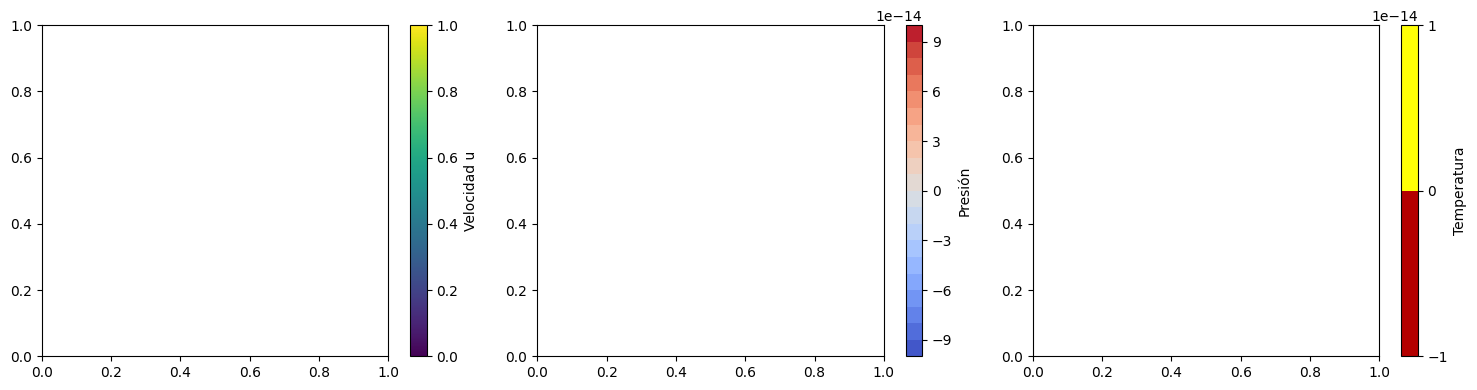

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, lil_matrix
from scipy.sparse.linalg import spsolve

# Parámetros físicos
rho, mu, nu = 1.184, 1.849e-5, 1.849e-5/1.184
L, H, u0, up = 1.0, 0.1, 2.0, -1.0
uc, Re = u0 - up, rho*u0*L/mu

# Discretización
N_eta, N_sigma = 100, 50
eta, sigma = np.linspace(0, 1, N_eta), np.linspace(0, 1, N_sigma)
dx, dy = eta[1]-eta[0], sigma[1]-sigma[0]
X, Y = np.meshgrid(eta, sigma)

# Inicialización
u_eta = np.zeros((N_sigma, N_eta))
u_sigma = np.zeros_like(u_eta)
theta = np.zeros_like(u_eta)
p = np.zeros_like(u_eta)

# Condiciones iniciales
u_eta[-1,:] = 1  # Flujo libre superior
for i in range(N_sigma):
    u_eta[i,:] = (sigma[i] - sigma[i]**2)*4  # Perfil parabólico

# Funciones derivadas
def deriv(f, dx, axis=0, order=1):
    if order == 1: return (np.roll(f,-1,axis)-np.roll(f,1,axis))/(2*dx)
    return (np.roll(f,-1,axis)-2*f+np.roll(f,1,axis))/(dx**2)

# Solver SIMPLE simplificado
def solve_pressure(u, v, p, dx, dy, dt, rho, max_iter=10):  # Añadido p como parámetro
    for _ in range(max_iter):
        div = deriv(u,dx,1) + deriv(v,dy,0)
        A = diags([-2/dx**2-2/dy**2,1/dx**2,1/dx**2,1/dy**2,1/dy**2],
                  [0,1,-1,N_eta,-N_eta], shape=(N_sigma*N_eta,)*2, format='lil')
        for i in [0,N_sigma-1]: A[i*N_eta:(i+1)*N_eta] = lil_matrix((N_eta,N_sigma*N_eta))
        p_corr = spsolve(A.tocsr(), -div.flatten()).reshape(N_sigma,N_eta)
        u -= 0.5*dt/rho*deriv(p_corr,dx,1)
        v -= 0.5*dt/rho*deriv(p_corr,dy,0)
        p += 0.1*p_corr
    return u, v, p

# Simulación
dt, nt = 0.001, 500
for _ in range(nt):
    # Paso de velocidad
    conv_u = u_eta*deriv(u_eta,dx,1) + u_sigma*deriv(u_eta,dy,0)
    visc_u = nu*(deriv(u_eta,dx,1,2) + deriv(u_eta,dy,0,2))
    u_eta += dt*(-conv_u + visc_u - deriv(p,dx,1)/rho)
    
    # Resolver presión (ahora pasando p como argumento)
    u_eta, u_sigma, p = solve_pressure(u_eta, u_sigma, p, dx, dy, dt, rho)
    
    # Paso de temperatura
    conv_T = u_eta*deriv(theta,dx,1) + u_sigma*deriv(theta,dy,0)
    diff_T = (2.22e-5)*(deriv(theta,dx,1,2) + deriv(theta,dy,0,2))
    theta += dt*(-conv_T + diff_T)
    
    # Condiciones de contorno
    u_eta[0,:], u_eta[-1,:] = 0, 1
    u_sigma[:,0], u_sigma[:,-1] = 0, 0
    theta[0,:], theta[-1,:] = 0, 0

# Visualización
plt.figure(figsize=(15,4))
plt.subplot(131)
plt.contourf(X, Y, u_eta, levels=20, cmap='jet')
plt.streamplot(X, Y, u_eta, u_sigma, color='w', density=1.5)
plt.colorbar(label='Velocidad u')
plt.subplot(132)
plt.contourf(X, Y, p, levels=20, cmap='coolwarm')
plt.colorbar(label='Presión')
plt.subplot(133)
plt.contourf(X, Y, theta, levels=20, cmap='hot')
plt.colorbar(label='Temperatura')
plt.tight_layout()
plt.show()

/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_8139/1468073482.py:117: RuntimeWarning: overflow encountered in scalar multiply
  temp_adv = u_eta_old[y,x] * d_eta(theta_old, y, x, dx) + u_sigma_old[y,x] * d_sigma(theta_old, y, x, dy)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_8139/1468073482.py:120: RuntimeWarning: overflow encountered in scalar power
  (d_eta(u_sigma_old,y,x,dx) + Lambda**2*d_sigma(u_eta_old,y,x,dy))**2)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_8139/1468073482.py:122: RuntimeWarning: invalid value encountered in scalar add
  theta[y,x] = theta_old[y,x] + dt*(-temp_adv + temp_diff + viscous_heating)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_8139/1468073482.py:110: RuntimeWarning: overflow encountered in scalar multiply
  adv_term = u_eta_old[y,x] * d_eta(u_eta_old, y, x, dx)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_8139/1468073482.py:119: RuntimeWarning: overflow encountered in scalar powe

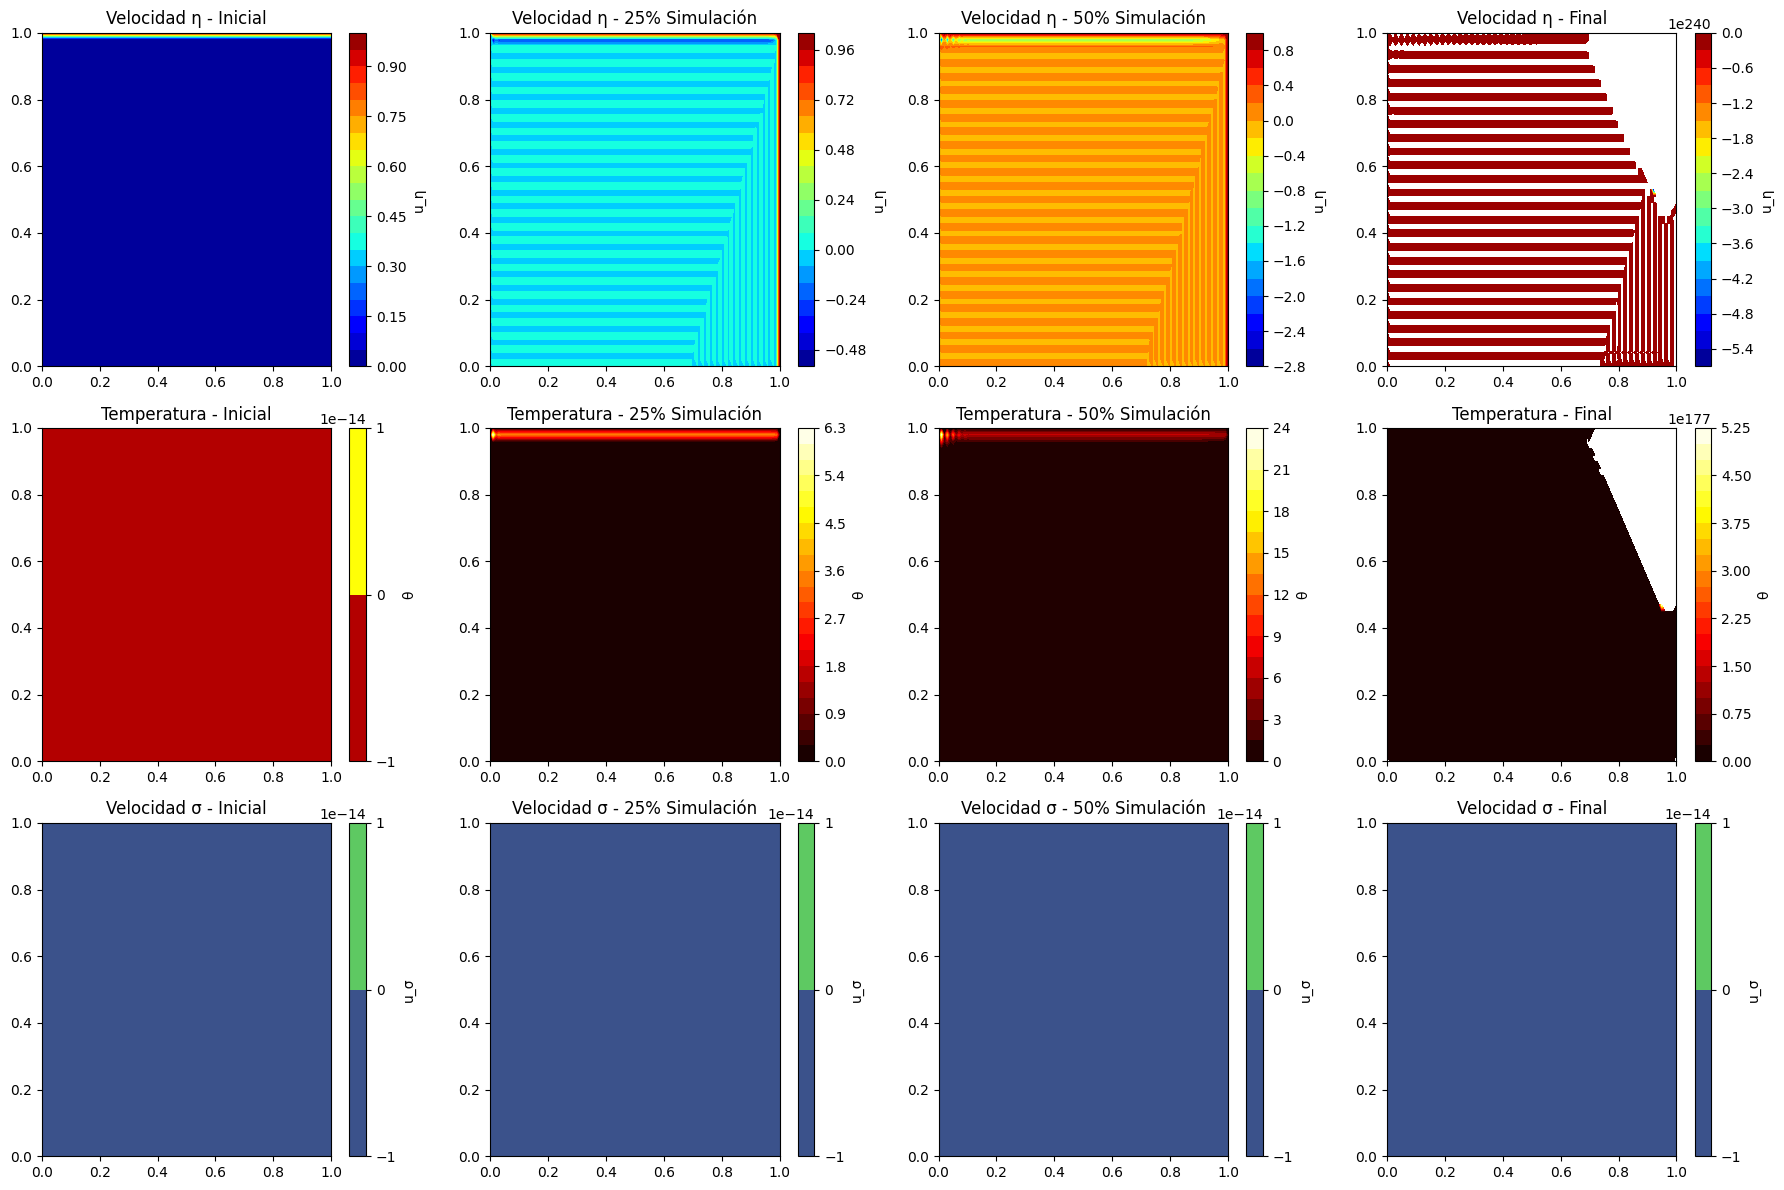

"\nPara crear una animación, puedes usar:\nfrom matplotlib.animation import FuncAnimation\n\nfig, ax = plt.subplots()\ndef update(frame):\n    ax.clear()\n    ax.contourf(X, Y, u_eta_history[frame].T, cmap='jet')\n    ax.set_title(f'Velocidad η - Tiempo: {frame*dt:.2f}s')\nanim = FuncAnimation(fig, update, frames=nt, interval=50)\nplt.show()\n"

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PARÁMETROS Y CONSTANTES
# =============================================================================
# Propiedades del aire (25°C, 1 atm)
rho = 1.184       # Densidad [kg/m³]
mu = 1.849e-5     # Viscosidad dinámica [Pa·s]
nu = mu/rho       # Viscosidad cinemática [m²/s]
k = 0.0262        # Conductividad térmica [W/(m·K)]
alpha = 2.22e-5   # Difusividad térmica [m²/s]
cp = 1006.0       # Calor específico [J/(kg·K)]

# Escalas características
L = 1.0           # Longitud característica [m]
H = 0.1           # Altura característica [m]
u0 = 2.0          # Velocidad característica [m/s]
up = -1.0         # Velocidad placa [m/s]
T0 = 293.0        # Temperatura referencia [K]
p0 = 101325.0     # Presión referencia [Pa]

# Cálculo de parámetros característicos
uc = u0 - up      # Velocidad característica corregida
pf = mu*uc*L/H**2 + p0
Tf = T0 + (mu*uc**2)/k

# Parámetros adimensionales
Lambda = L/H
Re = rho*u0*L/mu
tc = L/uc
varphi = nu/(L*u0)
beta = alpha/(u0*L)
Eu = (pf-p0)/(rho*u0**2)
delta = mu*u0/(rho*cp*L*(Tf-T0))

# =============================================================================
# DISCRETIZACIÓN ESPACIAL
# =============================================================================
N_eta = 100       # Puntos en dirección η (x - columnas)
N_sigma = 50      # Puntos en dirección σ (y - filas)
eta = np.linspace(0, 1, N_eta)
sigma = np.linspace(0, 1, N_sigma)
dx = eta[1] - eta[0]
dy = sigma[1] - sigma[0]

# Malla
X, Y = np.meshgrid(eta, sigma)  # X: columnas (η), Y: filas (σ)

# =============================================================================
# INICIALIZACIÓN DE VARIABLES E HISTORIAL
# =============================================================================
dt = 0.001
nt = 500

# Campos actuales
u_eta = np.zeros((N_sigma, N_eta))
u_sigma = np.zeros((N_sigma, N_eta))
theta = np.zeros((N_sigma, N_eta))
xi = np.zeros((N_sigma, N_eta))

# Historial temporal (forma: [time, sigma, eta])
u_eta_history = np.zeros((nt, N_sigma, N_eta))
u_sigma_history = np.zeros((nt, N_sigma, N_eta))
theta_history = np.zeros((nt, N_sigma, N_eta))

# Condiciones iniciales de frontera
u_eta[0, :] = 0     # Placa inferior
u_eta[-1, :] = 1    # Flujo libre superior
theta[0, :] = 0      # Temp. placa
theta[-1, :] = 0     # Temp. fluido

# =============================================================================
# FUNCIONES DE DERIVADAS (CORREGIDAS)
# =============================================================================
def d_eta(var, y_idx, x_idx, h):
    """Derivada en η (x) - dirección de columnas"""
    return (var[y_idx, x_idx+1] - var[y_idx, x_idx-1]) / (2*h)

def d_sigma(var, y_idx, x_idx, h):
    """Derivada en σ (y) - dirección de filas"""
    return (var[y_idx+1, x_idx] - var[y_idx-1, x_idx]) / (2*h)

def d2_eta(var, y_idx, x_idx, h):
    """Segunda derivada en η (x)"""
    return (var[y_idx, x_idx+1] - 2*var[y_idx, x_idx] + var[y_idx, x_idx-1]) / h**2

def d2_sigma(var, y_idx, x_idx, h):
    """Segunda derivada en σ (y)"""
    return (var[y_idx+1, x_idx] - 2*var[y_idx, x_idx] + var[y_idx-1, x_idx]) / h**2

# =============================================================================
# SIMULACIÓN TEMPORAL
# =============================================================================
for t in range(nt):
    # Guardar estado actual en el historial
    u_eta_history[t] = u_eta.copy()
    u_sigma_history[t] = u_sigma.copy()
    theta_history[t] = theta.copy()
    
    # Copiar campos anteriores
    u_eta_old = u_eta.copy()
    u_sigma_old = u_sigma.copy()
    theta_old = theta.copy()

    # Actualizar campos internos
    for y in range(1, N_sigma-1):     # σ (y - filas)
        for x in range(1, N_eta-1):   # η (x - columnas)
            # Ecuación de momento para u_eta
            adv_term = u_eta_old[y,x] * d_eta(u_eta_old, y, x, dx)
            cross_term = Lambda * u_sigma_old[y,x] * d_sigma(u_eta_old, y, x, dy)
            visc_term = varphi * (d2_eta(u_eta_old, y, x, dx) + Lambda**2 * d2_sigma(u_eta_old, y, x, dy))
            
            u_eta[y,x] = u_eta_old[y,x] - dt * (adv_term + cross_term + visc_term)
            
            # Ecuación de energía para theta
            temp_adv = u_eta_old[y,x] * d_eta(theta_old, y, x, dx) + u_sigma_old[y,x] * d_sigma(theta_old, y, x, dy)
            temp_diff = beta * (d2_eta(theta_old, y, x, dx) + Lambda * d2_sigma(theta_old, y, x, dy))
            viscous_heating = delta * (2*(d_eta(u_eta_old,y,x,dx)**2 + Lambda*d_sigma(u_sigma_old,y,x,dy)**2) + 
                                      (d_eta(u_sigma_old,y,x,dx) + Lambda**2*d_sigma(u_eta_old,y,x,dy))**2)
            
            theta[y,x] = theta_old[y,x] + dt*(-temp_adv + temp_diff + viscous_heating)

    # Aplicar condiciones de frontera
    u_eta[:, [0, -1]] = [0, 1]  # Lateral izquierda y derecha
    u_sigma[:, :] = 0           # Simplificación para velocidad vertical
    theta[:, [0, -1]] = 0       # Temperaturas fijas en bordes

# =============================================================================
# POST-PROCESADO Y VISUALIZACIÓN
# =============================================================================
# Crear figura
plt.figure(figsize=(18, 12))

# Seleccionar instantes clave para visualizar
plot_times = [0, nt//4, nt//2, nt-1]
titles = ['Inicial', '25% Simulación', '50% Simulación', 'Final']

for i, t_idx in enumerate(plot_times):
    # Velocidad
    plt.subplot(3, 4, i+1)
    plt.contourf(X, Y, u_eta_history[t_idx], levels=20, cmap='jet')
    plt.colorbar(label='u_η')
    plt.title(f'Velocidad η - {titles[i]}')
    
    # Temperatura
    plt.subplot(3, 4, i+5)
    plt.contourf(X, Y, theta_history[t_idx], levels=20, cmap='hot')
    plt.colorbar(label='θ')
    plt.title(f'Temperatura - {titles[i]}')
    
    # Velocidad vertical
    plt.subplot(3, 4, i+9)
    plt.contourf(X, Y, u_sigma_history[t_idx], levels=20, cmap='viridis')
    plt.colorbar(label='u_σ')
    plt.title(f'Velocidad σ - {titles[i]}')

plt.tight_layout()
plt.show()

# =============================================================================
# ANIMACIÓN (OPCIONAL - Requiere matplotlib.animation)
# =============================================================================
"""
Para crear una animación, puedes usar:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()
def update(frame):
    ax.clear()
    ax.contourf(X, Y, u_eta_history[frame].T, cmap='jet')
    ax.set_title(f'Velocidad η - Tiempo: {frame*dt:.2f}s')
anim = FuncAnimation(fig, update, frames=nt, interval=50)
plt.show()
"""


perplexity

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# =============================================================================
# PARÁMETROS Y CONSTANTES ADIMENSIONALES
# =============================================================================
# Propiedades del flujo y geometría
Lambda = 10.0       # Relación de aspecto (L/H)
Re = 100.0          # Número de Reynolds
Eu = 1.0            # Número de Euler
varphi = 1.0 / Re   # Término viscoso
beta = 0.01         # Difusividad térmica adimensional
delta = 0.01        # Disipación viscosa adimensional

# Escalas temporales y espaciales
dt = 0.001          # Paso de tiempo adimensional
nt = 500            # Número de pasos de tiempo

# Discretización espacial (direcciones adimensionales)
N_eta = 100         # Puntos en dirección η (x)
N_sigma = 50        # Puntos en dirección σ (y)
eta = np.linspace(0, 1, N_eta)
sigma = np.linspace(0, 1, N_sigma)
d_eta = eta[1] - eta[0]
d_sigma = sigma[1] - sigma[0]

# Malla para visualización
X, Y = np.meshgrid(eta, sigma)

# =============================================================================
# INICIALIZACIÓN DE VARIABLES Y CONDICIONES DE FRONTERA
# =============================================================================
u_eta = np.zeros((N_sigma, N_eta))     # Velocidad horizontal adimensional (u_η)
u_sigma = np.zeros((N_sigma, N_eta))   # Velocidad vertical adimensional (u_σ)
theta = np.zeros((N_sigma, N_eta))     # Temperatura adimensional (θ)
xi = np.zeros((N_sigma, N_eta))        # Presión adimensional (ξ)

# Historial temporal para cada variable (forma: [time, sigma, eta])
u_eta_history = np.zeros((nt, N_sigma, N_eta))
u_sigma_history = np.zeros((nt, N_sigma, N_eta))
theta_history = np.zeros((nt, N_sigma, N_eta))

# Condiciones iniciales y de frontera
u_eta[:, 0] = 0     # Placa inferior móvil (u_η|σ=0)
u_eta[:, -1] = 1    # Flujo libre superior (u_η|σ=1)
theta[:, [0, -1]] = 0  # Temperatura fija en los bordes (θ|σ=0 y σ=1)

# =============================================================================
# FUNCIONES PARA DERIVADAS ESPACIALES ADIMENSIONALES
# =============================================================================
def d_eta(var, y_idx, x_idx):
    """Derivada en dirección η (x)"""
    return (var[y_idx, x_idx+1] - var[y_idx, x_idx-1]) / (2 * d_eta)

def d_sigma(var, y_idx, x_idx):
    """Derivada en dirección σ (y)"""
    return (var[y_idx+1, x_idx] - var[y_idx-1, x_idx]) / (2 * d_sigma)

def d2_eta(var, y_idx, x_idx):
    """Segunda derivada en dirección η (x)"""
    return (var[y_idx, x_idx+1] - 2*var[y_idx, x_idx] + var[y_idx, x_idx-1]) / d_eta**2

def d2_sigma(var, y_idx, x_idx):
    """Segunda derivada en dirección σ (y)"""
    return (var[y_idx+1, x_idx] - 2*var[y_idx, x_idx] + var[y_idx-1, x_idx]) / d_sigma**2

# =============================================================================
# SIMULACIÓN TEMPORAL ADIMENSIONALIZADA
# =============================================================================
for t in range(nt):
    # Guardar estado actual en el historial
    u_eta_history[t] = u_eta.copy()
    u_sigma_history[t] = u_sigma.copy()
    theta_history[t] = theta.copy()

    # Copiar campos anteriores para cálculo explícito
    u_eta_old = u_eta.copy()
    u_sigma_old = u_sigma.copy()
    theta_old = theta.copy()

    for y in range(1, N_sigma-1):     # Dirección σ (y - filas)
        for x in range(1, N_eta-1):   # Dirección η (x - columnas)
            # Ecuación de Navier-Stokes para u_η
            adv_term_ueta = u_eta_old[y,x] * d_eta(u_eta_old, y,x) + Lambda * u_sigma_old[y,x] * d_sigma(u_eta_old,y,x)
            visc_term_ueta = varphi * (d2_eta(u_eta_old,y,x) + Lambda**2 * d2_sigma(u_eta_old,y,x))
            u_eta[y,x] -= dt * (adv_term_ueta + visc_term_ueta)

            # Ecuación de energía para θ
            adv_term_theta = u_eta_old[y,x] * d_eta(theta_old,y,x) + Lambda * u_sigma_old[y,x] * d_sigma(theta_old,y,x)
            diff_term_theta = beta * (d2_eta(theta_old,y,x) + Lambda**2 * d2_sigma(theta_old,y,x))
            visc_heating_theta = delta * (
                2*(d_eta(u_eta_old,y,x)**2 + Lambda**2*d_sigma(u_sigma_old,y,x)**2) +
                (d_eta(u_sigma_old,y,x) + Lambda*d_sigma(u_eta_old,y,x))**2
            )
            theta[y,x] += dt * (-adv_term_theta + diff_term_theta + visc_heating_theta)

    # Aplicar condiciones de frontera nuevamente
    u_eta[:, [0]] = 0      # Placa inferior móvil
    u_eta[:, [-1]] = 1     # Flujo libre superior
    theta[:, [0]] = theta[:, [-1]] = 0

# =============================================================================
# VISUALIZACIÓN DE RESULTADOS ADIMENSIONALES EN DIFERENTES TIEMPOS
# =============================================================================
plt.figure(figsize=(18, 12))

plot_times = [0, nt//4, nt//2, nt-1]
titles = ['Inicial', '25% Simulación', '50% Simulación', 'Final']

for i, t in enumerate(plot_times):
    plt.subplot(3, len(plot_times), i+1)
    plt.contourf(X.T, Y.T, u_eta_history[t], levels=20, cmap='jet')
    plt.colorbar(label='u_η')
    plt.title(f'Velocidad Horizontal - {titles[i]}')

    plt.subplot(3, len(plot_times), i+len(plot_times)+1)
    plt.contourf(X.T, Y.T, theta_history[t], levels=20, cmap='hot')
    plt.colorbar(label='θ')
    plt.title(f'Temperatura - {titles[i]}')

plt.tight_layout()
plt.show()

# =============================================================================
# ANIMACIÓN OPCIONAL DE VELOCIDAD HORIZONTAL ADIMENSIONALIZADA
# =============================================================================

fig_anim, ax_anim = plt.subplots()
contour_anim = ax_anim.contourf(X.T, Y.T, u_eta_history[0], levels=20, cmap='jet')
plt.colorbar(contour_anim)

def update(frame):
    ax_anim.clear()
    contour_anim = ax_anim.contourf(X.T, Y.T, u_eta_history[frame], levels=20, cmap='jet')
    ax_anim.set_title(f'Tiempo: {frame*dt:.3f}')
    
anim = FuncAnimation(fig_anim, update, frames=nt//10)
plt.show()


TypeError: unsupported operand type(s) for *: 'int' and 'function'

deepseek

/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1084/572487068.py:95: RuntimeWarning: overflow encountered in scalar multiply
  conv_theta = (u_eta_old[i,j]*(theta_old[i,j+1]-theta_old[i,j-1])/(2*(eta[1]-eta[0])) + \
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1084/572487068.py:108: RuntimeWarning: overflow encountered in scalar power
  (du_eta_dsigma + Lambda*du_sigma_deta)**2)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1084/572487068.py:110: RuntimeWarning: invalid value encountered in scalar add
  theta[i,j] = theta_old[i,j] + dt*(-conv_theta + diff_theta + dissipation)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1084/572487068.py:77: RuntimeWarning: overflow encountered in scalar multiply
  conv_eta = (u_eta_old[i,j]*(u_eta_old[i,j+1]-u_eta_old[i,j-1])/(2*(eta[1]-eta[0])) + \
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1084/572487068.py:107: RuntimeWarning: overflow encountered in scalar power
  dissipation = d

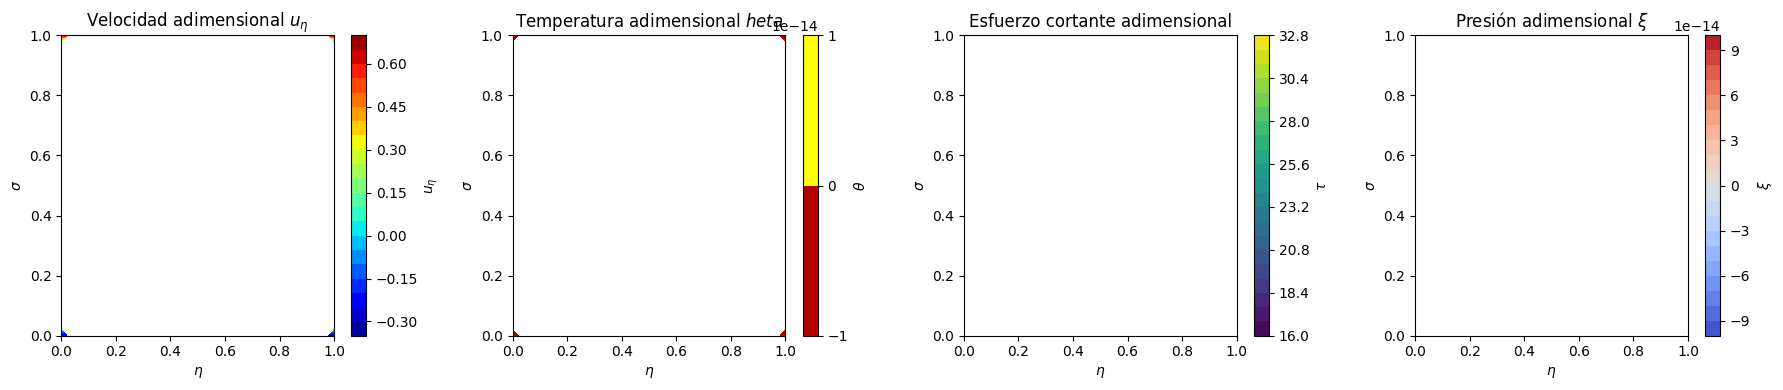

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PARÁMETROS Y CONSTANTES
# =============================================================================
# Propiedades del aire (25°C, 1 atm)
rho = 1.184       # Densidad [kg/m³]
mu = 2000     # Viscosidad dinámica [Pa·s]
nu = mu/rho       # Viscosidad cinemática [m²/s]
k = 0.0262        # Conductividad térmica [W/(m·K)]
alpha = 0.005  # Difusividad térmica [m²/s]
cp = 10000.0       # Calor específico [J/(kg·K)]

# Escalas características
L = 1.0           # Longitud característica [m]
H = 0.5           # Altura característica [m]
u0 = 2.0          # Velocidad característica [m/s]
up = -1.0         # Velocidad placa [m/s]
T0 = 293.0        # Temperatura referencia [K]
p0 = 101325.0     # Presión referencia [Pa]

# Cálculo de u_c, p_f y T_f
uc = u0 - up      # Velocidad característica corregida
pf = p0 + 400 #mu*uc*L/H**2 + p0
Tf = T0 + (mu*uc**2)/k

# Parámetros adimensionales
Lambda = L/H
Re = rho*u0*L/mu
phi = nu/(L*u0)
beta = alpha*L**3/(u0*H**2)
Eu = (pf-p0)/(rho*u0**2)
delta = mu*u0/(rho*cp*L)

'''# PARÁMETROS ADIMENSIONALES
Lambda = 2.0       # Relación de aspecto L/H
Re = 100.0         # Número de Reynolds
Eu = 0.1           # Número de Euler
phi = 1/Re         # Parámetro viscoso
beta = 0.01        # Coeficiente de difusión térmica adimensional
delta = 0.001      # Parámetro de disipación viscosa adimensional'''

# MALLA COMPUTACIONAL
n_eta, n_sigma = 50, 50   # Puntos en la malla
eta = np.linspace(0, 1, n_eta)      # Coordenada η adimensional
sigma = np.linspace(0, 1, n_sigma)  # Coordenada σ adimensional
Eta, Sigma = np.meshgrid(eta, sigma)

# PASO TEMPORAL
dt = 0.001         # Paso temporal adimensional
nt = 500           # Número de pasos temporales

# INICIALIZACIÓN DE CAMPOS
u_eta = np.zeros((n_sigma, n_eta))   # Velocidad adimensional en η
u_sigma = np.zeros((n_sigma, n_eta)) # Velocidad adimensional en σ
theta = np.zeros((n_sigma, n_eta))   # Temperatura adimensional
xi = np.zeros((n_sigma, n_eta))      # Presión adimensional

# CONDICIONES DE CONTORNO
u_eta[0, :] = 0.0      # Placa inferior fija (σ=0)
u_eta[-1, :] = 1.0      # Placa superior móvil (σ=1)
theta[0, :] = 0.0       # Temperatura en σ=0
theta[-1, :] = 0.0      # Temperatura en σ=1

# ESQUEMA NUMÉRICO EXPLÍCITO
for n in range(nt):
    # Copiar campos anteriores
    u_eta_old = u_eta.copy()
    u_sigma_old = u_sigma.copy()
    theta_old = theta.copy()
    
    # Actualizar campos internos
    for i in range(1, n_sigma-1):
        for j in range(1, n_eta-1):
            # Términos convectivos
            conv_eta = (u_eta_old[i,j]*(u_eta_old[i,j+1]-u_eta_old[i,j-1])/(2*(eta[1]-eta[0])) + \
                      Lambda*u_sigma_old[i,j]*(u_eta_old[i+1,j]-u_eta_old[i-1,j])/(2*(sigma[1]-sigma[0])))
            
            conv_sigma = (u_eta_old[i,j]*(u_sigma_old[i,j+1]-u_sigma_old[i,j-1])/(2*(eta[1]-eta[0])) + \
                        Lambda*u_sigma_old[i,j]*(u_sigma_old[i+1,j]-u_sigma_old[i-1,j])/(2*(sigma[1]-sigma[0])))
            
            # Términos difusivos
            diff_eta = phi*((u_eta_old[i,j+1]-2*u_eta_old[i,j]+u_eta_old[i,j-1])/(eta[1]-eta[0])**2 + \
                        Lambda**2*(u_eta_old[i+1,j]-2*u_eta_old[i,j]+u_eta_old[i-1,j])/(sigma[1]-sigma[0])**2)
            
            diff_sigma = phi*((u_sigma_old[i,j+1]-2*u_sigma_old[i,j]+u_sigma_old[i,j-1])/(eta[1]-eta[0])**2 + \
                         Lambda**2*(u_sigma_old[i+1,j]-2*u_sigma_old[i,j]+u_sigma_old[i-1,j])/(sigma[1]-sigma[0])**2)
            
            # Ecuaciones de momento
            u_eta[i,j] = u_eta_old[i,j] + dt*(-conv_eta - Eu*(xi[i,j+1]-xi[i,j-1])/(2*(eta[1]-eta[0])) + diff_eta)
            u_sigma[i,j] = u_sigma_old[i,j] + dt*(-conv_sigma - Eu*(xi[i+1,j]-xi[i-1,j])/(2*Lambda*(sigma[1]-sigma[0])) + diff_sigma)
            
            # Ecuación de energía
            conv_theta = (u_eta_old[i,j]*(theta_old[i,j+1]-theta_old[i,j-1])/(2*(eta[1]-eta[0])) + \
                         Lambda*u_sigma_old[i,j]*(theta_old[i+1,j]-theta_old[i-1,j])/(2*(sigma[1]-sigma[0])))
            
            diff_theta = beta*((theta_old[i,j+1]-2*theta_old[i,j]+theta_old[i,j-1])/(eta[1]-eta[0])**2 + \
                          Lambda**2*(theta_old[i+1,j]-2*theta_old[i,j]+theta_old[i-1,j])/(sigma[1]-sigma[0])**2)
            
            # Términos de disipación viscosa
            du_eta_deta = (u_eta_old[i,j+1]-u_eta_old[i,j-1])/(2*(eta[1]-eta[0]))
            du_sigma_dsigma = (u_sigma_old[i+1,j]-u_sigma_old[i-1,j])/(2*(sigma[1]-sigma[0]))
            du_eta_dsigma = (u_eta_old[i+1,j]-u_eta_old[i-1,j])/(2*(sigma[1]-sigma[0]))
            du_sigma_deta = (u_sigma_old[i,j+1]-u_sigma_old[i,j-1])/(2*(eta[1]-eta[0]))
            
            dissipation = delta*(2*(du_eta_deta**2 + Lambda**2*du_sigma_dsigma**2) + 
                               (du_eta_dsigma + Lambda*du_sigma_deta)**2)
            
            theta[i,j] = theta_old[i,j] + dt*(-conv_theta + diff_theta + dissipation)
    
    # Aplicar condiciones de contorno
    u_eta[0, :] = up/uc
    u_eta[-1, :] = u0/uc
    u_sigma[:, 0] = u_sigma[:, -1] = 0.0
    theta[0, :] = theta[-1, :] = 0.0

# SOLUCIÓN DE LA ECUACIÓN DE PRESIÓN (Poisson)
max_iter = 500
tolerance = 1e-4

for _ in range(max_iter):
    xi_old = xi.copy()
    
    for i in range(1, n_sigma-1):
        for j in range(1, n_eta-1):
            # Ecuación de Poisson para la presión adimensional
            xi[i,j] = 0.25*(xi_old[i+1,j] + xi_old[i-1,j] + xi_old[i,j+1] + xi_old[i,j-1] - 
                           (1/Eu)*((u_eta[i+1,j]-u_eta[i-1,j])/(2*Lambda*(sigma[1]-sigma[0])) * 
                                  (u_sigma[i,j+1]-u_sigma[i,j-1])/(2*(eta[1]-eta[0])) -
                                  ((u_eta[i,j+1]-u_eta[i,j-1])/(2*(eta[1]-eta[0])))**2 -
                                  ((u_sigma[i+1,j]-u_sigma[i-1,j])/(2*Lambda*(sigma[1]-sigma[0])))**2))
    
    # Condiciones de contorno para la presión
    xi[0, :] = xi[1, :]    # σ = 0
    xi[-1, :] = xi[-2, :]  # σ = 1
    xi[:, 0] = xi[:, 1]    # η = 0
    xi[:, -1] = xi[:, -2]  # η = 1
    
    if np.max(np.abs(xi - xi_old)) < tolerance:
        break

# CÁLCULO DEL ESFUERZO CORTANTE ADIMENSIONAL
du_eta_dsigma = np.gradient(u_eta, sigma, axis=0)
du_sigma_deta = np.gradient(u_sigma, eta, axis=1)
tau = du_eta_dsigma + Lambda*du_sigma_deta  # Esfuerzo cortante adimensional

# VISUALIZACIÓN
plt.figure(figsize=(18, 4))

# Campo de velocidad u_η
plt.subplot(1, 4, 1)
plt.contourf(Eta, Sigma, u_eta, levels=20, cmap='jet')
plt.colorbar(label=r'$u_\eta$')
plt.title(r'Velocidad adimensional $u_\eta$')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# Campo de temperatura θ
plt.subplot(1, 4, 2)
plt.contourf(Eta, Sigma, theta, levels=20, cmap='hot')
plt.colorbar(label=r'$\theta$')
plt.title('Temperatura adimensional $\theta$')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# Esfuerzo cortante τ
plt.subplot(1, 4, 3)
plt.contourf(Eta, Sigma, tau, levels=20, cmap='viridis')
plt.colorbar(label=r'$\tau$')
plt.title('Esfuerzo cortante adimensional')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# Campo de presión ξ
plt.subplot(1, 4, 4)
plt.contourf(Eta, Sigma, xi, levels=20, cmap='coolwarm')
plt.colorbar(label=r'$\xi$')
plt.title(r'Presión adimensional $\xi$')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

plt.tight_layout()
plt.show()

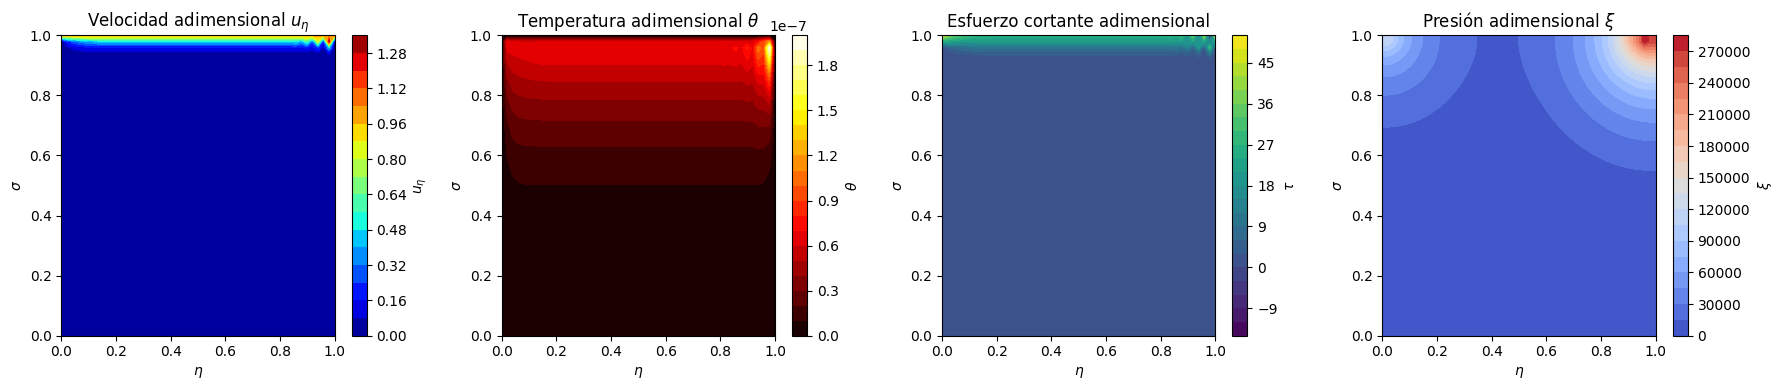

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PARÁMETROS Y CONSTANTES
# =============================================================================
# Propiedades del aire (25°C, 1 atm)
rho = 1.184       # Densidad [kg/m³]
mu = 1.849e-5     # Viscosidad dinámica [Pa·s]
nu = mu/rho       # Viscosidad cinemática [m²/s]
k = 0.0262        # Conductividad térmica [W/(m·K)]
alpha = 2.22e-5   # Difusividad térmica [m²/s]
cp = 1006.0       # Calor específico [J/(kg·K)]

# Escalas características
L = 1.0           # Longitud característica [m]
H = 0.1           # Altura característica [m]
u0 = 2.0          # Velocidad característica [m/s]
up = -1.0         # Velocidad placa [m/s]
T0 = 293.0        # Temperatura referencia [K]
p0 = 101325.0     # Presión referencia [Pa]

# Cálculo de u_c, p_f y T_f
uc = u0 - up      # Velocidad característica corregida
pf = mu*uc*L/H**2 + p0
Tf = T0 + (mu*uc**2)/k

# Parámetros adimensionales
Lambda = L/H
Re = rho*u0*L/mu
phi = nu/(L*u0)
beta = alpha*L**3/(u0*H**2)
Eu = (pf-p0)/(rho*u0**2)
delta = mu*u0/(rho*cp*L)

'''# PARÁMETROS ADIMENSIONALES
Lambda = 2.0       # Relación de aspecto L/H
Re = 100.0         # Número de Reynolds
Eu = 0.1           # Número de Euler
phi = 1/Re         # Parámetro viscoso
beta = 0.01        # Coeficiente de difusión térmica adimensional
delta = 0.001      # Parámetro de disipación viscosa adimensional'''

# MALLA COMPUTACIONAL
n_eta, n_sigma = 50, 50   # Puntos en la malla
eta = np.linspace(0, 1, n_eta)      # Coordenada η adimensional
sigma = np.linspace(0, 1, n_sigma)  # Coordenada σ adimensional
Eta, Sigma = np.meshgrid(eta, sigma)

# PASO TEMPORAL
dt = 0.001         # Paso temporal adimensional
nt = 500           # Número de pasos temporales

# INICIALIZACIÓN DE CAMPOS
u_eta = np.zeros((n_sigma, n_eta))   # Velocidad adimensional en η
u_sigma = np.zeros((n_sigma, n_eta)) # Velocidad adimensional en σ
theta = np.zeros((n_sigma, n_eta))   # Temperatura adimensional
xi = np.zeros((n_sigma, n_eta))      # Presión adimensional

# CONDICIONES DE CONTORNO
u_eta[0, :] = 0.0      # Placa inferior fija (σ=0)
u_eta[-1, :] = 1.0      # Placa superior móvil (σ=1)
theta[0, :] = 0.0       # Temperatura en σ=0
theta[-1, :] = 0.0      # Temperatura en σ=1

# ESQUEMA NUMÉRICO EXPLÍCITO
for n in range(nt):
    # Copiar campos anteriores
    u_eta_old = u_eta.copy()
    u_sigma_old = u_sigma.copy()
    theta_old = theta.copy()
    
    # Actualizar campos internos
    for i in range(1, n_sigma-1):
        for j in range(1, n_eta-1):
            # Términos convectivos
            conv_eta = (u_eta_old[i,j]*(u_eta_old[i,j+1]-u_eta_old[i,j-1])/(2*(eta[1]-eta[0])) + \
                      Lambda*u_sigma_old[i,j]*(u_eta_old[i+1,j]-u_eta_old[i-1,j])/(2*(sigma[1]-sigma[0])))
            
            conv_sigma = (u_eta_old[i,j]*(u_sigma_old[i,j+1]-u_sigma_old[i,j-1])/(2*(eta[1]-eta[0])) + \
                        Lambda*u_sigma_old[i,j]*(u_sigma_old[i+1,j]-u_sigma_old[i-1,j])/(2*(sigma[1]-sigma[0])))
            
            # Términos difusivos
            diff_eta = phi*((u_eta_old[i,j+1]-2*u_eta_old[i,j]+u_eta_old[i,j-1])/(eta[1]-eta[0])**2 + \
                        Lambda**2*(u_eta_old[i+1,j]-2*u_eta_old[i,j]+u_eta_old[i-1,j])/(sigma[1]-sigma[0])**2)
            
            diff_sigma = phi*((u_sigma_old[i,j+1]-2*u_sigma_old[i,j]+u_sigma_old[i,j-1])/(eta[1]-eta[0])**2 + \
                         Lambda**2*(u_sigma_old[i+1,j]-2*u_sigma_old[i,j]+u_sigma_old[i-1,j])/(sigma[1]-sigma[0])**2)
            
            # Ecuaciones de momento
            u_eta[i,j] = u_eta_old[i,j] + dt*(-conv_eta - Eu*(xi[i,j+1]-xi[i,j-1])/(2*(eta[1]-eta[0])) + diff_eta)
            u_sigma[i,j] = u_sigma_old[i,j] + dt*(-conv_sigma - Eu*(xi[i+1,j]-xi[i-1,j])/(2*Lambda*(sigma[1]-sigma[0])) + diff_sigma)
            
            # Ecuación de energía
            conv_theta = (u_eta_old[i,j]*(theta_old[i,j+1]-theta_old[i,j-1])/(2*(eta[1]-eta[0])) + \
                         Lambda*u_sigma_old[i,j]*(theta_old[i+1,j]-theta_old[i-1,j])/(2*(sigma[1]-sigma[0])))
            
            diff_theta = beta*((theta_old[i,j+1]-2*theta_old[i,j]+theta_old[i,j-1])/(eta[1]-eta[0])**2 + \
                          Lambda**2*(theta_old[i+1,j]-2*theta_old[i,j]+theta_old[i-1,j])/(sigma[1]-sigma[0])**2)
            
            # Términos de disipación viscosa
            du_eta_deta = (u_eta_old[i,j+1]-u_eta_old[i,j-1])/(2*(eta[1]-eta[0]))
            du_sigma_dsigma = (u_sigma_old[i+1,j]-u_sigma_old[i-1,j])/(2*(sigma[1]-sigma[0]))
            du_eta_dsigma = (u_eta_old[i+1,j]-u_eta_old[i-1,j])/(2*(sigma[1]-sigma[0]))
            du_sigma_deta = (u_sigma_old[i,j+1]-u_sigma_old[i,j-1])/(2*(eta[1]-eta[0]))
            
            dissipation = delta*(2*(du_eta_deta**2 + Lambda**2*du_sigma_dsigma**2) + 
                               (du_eta_dsigma + Lambda*du_sigma_deta)**2)
            
            theta[i,j] = theta_old[i,j] + dt*(-conv_theta + diff_theta + dissipation)
    
    # Aplicar condiciones de contorno
    u_eta[0, :] = 0.0
    u_eta[-1, :] = 1.0
    u_sigma[:, 0] = u_sigma[:, -1] = 0.0
    theta[0, :] = theta[-1, :] = 0.0

# SOLUCIÓN DE LA ECUACIÓN DE PRESIÓN (Poisson)
max_iter = 500
tolerance = 1e-4

for _ in range(max_iter):
    xi_old = xi.copy()
    
    for i in range(1, n_sigma-1):
        for j in range(1, n_eta-1):
            # Ecuación de Poisson para la presión adimensional
            xi[i,j] = 0.25*(xi_old[i+1,j] + xi_old[i-1,j] + xi_old[i,j+1] + xi_old[i,j-1] - 
                           (1/Eu)*((u_eta[i+1,j]-u_eta[i-1,j])/(2*Lambda*(sigma[1]-sigma[0])) * 
                                  (u_sigma[i,j+1]-u_sigma[i,j-1])/(2*(eta[1]-eta[0])) -
                                  ((u_eta[i,j+1]-u_eta[i,j-1])/(2*(eta[1]-eta[0])))**2 -
                                  ((u_sigma[i+1,j]-u_sigma[i-1,j])/(2*Lambda*(sigma[1]-sigma[0])))**2))
    
    # Condiciones de contorno para la presión
    xi[0, :] = xi[1, :]    # σ = 0
    xi[-1, :] = xi[-2, :]  # σ = 1
    xi[:, 0] = xi[:, 1]    # η = 0
    xi[:, -1] = xi[:, -2]  # η = 1
    
    if np.max(np.abs(xi - xi_old)) < tolerance:
        break

# CÁLCULO DEL ESFUERZO CORTANTE ADIMENSIONAL
du_eta_dsigma = np.gradient(u_eta, sigma, axis=0)
du_sigma_deta = np.gradient(u_sigma, eta, axis=1)
tau = du_eta_dsigma + Lambda*du_sigma_deta  # Esfuerzo cortante adimensional

# VISUALIZACIÓN
plt.figure(figsize=(18, 4))

# Campo de velocidad u_η
plt.subplot(1, 4, 1)
plt.contourf(Eta, Sigma, u_eta, levels=20, cmap='jet')
plt.colorbar(label=r'$u_\eta$')
plt.title(r'Velocidad adimensional $u_\eta$')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# Campo de temperatura θ
plt.subplot(1, 4, 2)
plt.contourf(Eta, Sigma, theta, levels=20, cmap='hot')
plt.colorbar(label=r'$\theta$')
plt.title(r'Temperatura adimensional $\theta$')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# Esfuerzo cortante τ
plt.subplot(1, 4, 3)
plt.contourf(Eta, Sigma, tau, levels=20, cmap='viridis')
plt.colorbar(label=r'$\tau$')
plt.title(r'Esfuerzo cortante adimensional')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# Campo de presión ξ
plt.subplot(1, 4, 4)
plt.contourf(Eta, Sigma, xi, levels=20, cmap='coolwarm')
plt.colorbar(label=r'$\xi$')
plt.title(r'Presión adimensional $\xi$')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

plt.tight_layout()
plt.show()


Presión máxima: 1.1367 en (1.96, 0.98)
Presión mínima: 0.0015 en (0.94, 0.00)


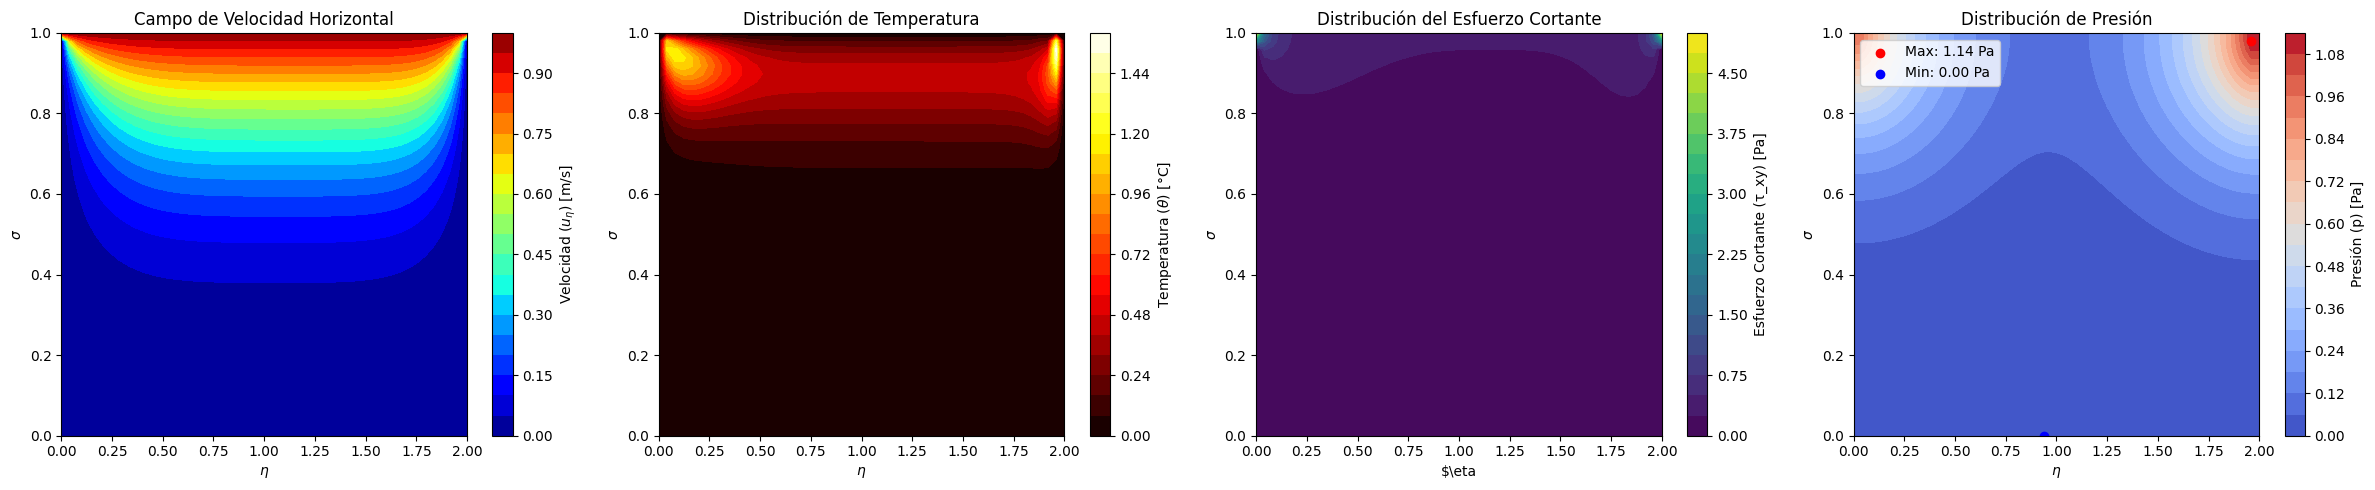

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


'''# =============================================================================
# PARÁMETROS Y CONSTANTES
# =============================================================================
# Propiedades del aire (25°C, 1 atm)
rho = 1.184       # Densidad [kg/m³]
mu = 1.849e-5     # Viscosidad dinámica [Pa·s]
nu = mu/rho       # Viscosidad cinemática [m²/s]
k = 0.0262        # Conductividad térmica [W/(m·K)]
alpha = 2.22e-5   # Difusividad térmica [m²/s]
cp = 1006.0       # Calor específico [J/(kg·K)]

# Escalas características
L = 1.0           # Longitud característica [m]
H = 0.1           # Altura característica [m]
u0 = 2.0          # Velocidad característica [m/s]
up = -1.0         # Velocidad placa [m/s]
T0 = 293.0        # Temperatura referencia [K]
p0 = 101325.0     # Presión referencia [Pa]

# Cálculo de u_c, p_f y T_f
uc = u0 - up      # Velocidad característica corregida
pf = mu*uc*L/H**2 + p0
Tf = T0 + (mu*uc**2)/k

# Parámetros adimensionales
Lambda = L/H
Re = rho*u0*L/mu
tc = L/uc
varphi = nu/(L*u0)
beta = alpha*L**3/(u0*H**2)
Eu = (pf-p0)/(rho*u0**2)
delta = mu*u0/(rho*cp*L)'''


# PARAMETROS DEL PROBLEMA
# Geometría
Lx, Ly = 2.0, 1.0  # Dimensiones del dominio (Eta, Sigma)
nx, ny = 50, 50      # Número de puntos en la malla
dx, dy = Lx/(nx-1), Ly/(ny-1)

# Propiedades del fluido
rho = 1.0            # Densidad
mu = 0.1             # Viscosidad dinámica
nu = mu / rho        # Viscosidad cinemática
alpha = 0.01         # Difusividad térmica
cp = 1.0             # Calor específico

# Condiciones de frontera
U_p = -1.0           # Velocidad de la placa (sentido contrario)
U_0 = 2.0            # Velocidad del flujo libre
T0, T1 = 0.0, 0.0    # Temperaturas de la placa y del fluido

# Tiempo
dt = 0.001           # Paso de tiempo
nt = 500             # Número de pasos de tiempo

## INICIALIZACIÓN

# Mallas
eta = np.linspace(0, Lx, nx)
sigma = np.linspace(0, Ly, ny)
Eta, Sigma = np.meshgrid(eta, sigma)

# Campos iniciales
u_eta = np.zeros((ny, nx))  # Velocidad horizontal
u_sigma = np.zeros((ny, nx))         # Velocidad vertical
theta = np.zeros((ny, nx))   # Temperatura
xi = np.zeros((ny, nx))         # Presión

# Aplicar condiciones de frontera
u_eta[0, :] = 0     # Placa inferior móvil
u_eta[-1, :] = 1    # Flujo libre superior
theta[0, :] = 0      # Temperatura de la placa
theta[-1, :] = 0     # Temperatura del fluido lejos de la 


# EVOLUCIÓN TEMPORAL (ESQUEMA EXPLICITO)
for n in range(nt):
    # Copiar campos anteriores
    u_eta_old = u_eta.copy()
    u_sigma_old = u_sigma.copy()
    theta_old = theta.copy()

    # Resolver Navier-Stokes (simplificado)
    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Ecuación de u (componente x)
            u_eta[i, j] = (u_eta_old[i, j] + dt * (
                -u_eta_old[i, j] * (u_eta_old[i, j+1] - u_eta_old[i, j-1]) / (2*dx)
                -u_sigma_old[i, j] * (u_eta_old[i+1, j] - u_eta_old[i-1, j]) / (2*dy)
                + nu * (
                    (u_eta_old[i, j+1] - 2*u_eta_old[i, j] + u_eta_old[i, j-1]) / dx**2
                    + (u_eta_old[i+1, j] - 2*u_eta_old[i, j] + u_eta_old[i-1, j]) / dy**2
                )
            ))

            # Ecuación de T (temperatura)
            theta[i, j] = (theta_old[i, j] + dt * (
                -u_eta_old[i, j] * (theta_old[i, j+1] - theta_old[i, j-1]) / (2*dx)
                -u_sigma_old[i, j] * (theta_old[i+1, j] - theta_old[i-1, j]) / (2*dy)
                + alpha * (
                    (theta_old[i, j+1] - 2*theta_old[i, j] + theta_old[i, j-1]) / dx**2
                    + (theta_old[i+1, j] - 2*theta_old[i, j] + theta_old[i-1, j]) / dy**2
                )
                + (mu / (rho * cp)) * (  # Disipación viscosa (simplificada)
                    2 * ((u_eta_old[i, j+1] - u_eta_old[i, j-1]) / (2*dx))**2
                    + 2 * ((u_sigma_old[i+1, j] - u_sigma_old[i-1, j]) / (2*dy))**2
                    + ((u_eta_old[i+1, j] - u_eta_old[i-1, j]) / (2*dy) 
                      + (u_sigma_old[i, j+1] - u_sigma_old[i, j-1]) / (2*dx))**2
                )
            ))

    # Aplicar condiciones de frontera nuevamente
    u_eta[0, :] = 0
    u_eta[-1, :] = 1
    u_sigma[:, 0] = u_sigma[:, -1] = 0
    theta[0, :] = theta[-1, :] = 0

# Cálculo de la presión mediante ecuación de Poisson (simplificado)
# Usamos una aproximación simple basada en la divergencia del campo de velocidad
max_iter = 500  # Número máximo de iteraciones para el solver de presión
tolerance = 1e-4  # Tolerancia para la convergencia

# Inicialización del campo de presión
xi = np.zeros((ny, nx))

# Solver iterativo para la presión
for _ in range(max_iter):
    xi_old = xi.copy()
    
    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Aproximación discreta de la ecuación de Poisson para la presión
            xi[i, j] = 0.25 * (xi_old[i+1, j] + xi_old[i-1, j] + 
                             xi_old[i, j+1] + xi_old[i, j-1] -
                             (rho * dx**2) * (
                                 (u_eta[i+1, j] - u_eta[i-1, j]) / (2*dy) * (u_sigma[i, j+1] - u_sigma[i, j-1]) / (2*dx) -
                                 ((u_eta[i, j+1] - u_eta[i, j-1]) / (2*dx))**2 -
                                 ((u_sigma[i+1, j] - u_sigma[i-1, j]) / (2*dy))**2
                             ))
    
    # Condiciones de frontera para la presión (Neumann homogéneas)
    xi[0, :] = xi[1, :]   # Frontera inferior
    xi[-1, :] = xi[-2, :] # Frontera superior
    xi[:, 0] = xi[:, 1]   # Frontera izquierda
    xi[:, -1] = xi[:, -2] # Frontera derecha
    
    # Criterio de convergencia
    if np.max(np.abs(xi - xi_old)) < tolerance:
        break

# Encontrar los valores máximos y mínimos de presión
xi_max = np.max(xi)
xi_min = np.min(xi)
xi_max_coords = np.unravel_index(np.argmax(xi), xi.shape)
xi_min_coords = np.unravel_index(np.argmin(xi), xi.shape)

# Convertir índices a coordenadas físicas
xi_max_eta, xi_max_sigma = eta[xi_max_coords[1]], sigma[xi_max_coords[0]]
xi_min_eta, xi_min_sigma = eta[xi_min_coords[1]], sigma[xi_min_coords[0]]

print(f"\nPresión máxima: {xi_max:.4f} en ({xi_max_eta:.2f}, {xi_max_sigma:.2f})")
print(f"Presión mínima: {xi_min:.4f} en ({xi_min_eta:.2f}, {xi_min_sigma:.2f})")

# REPRESENTACIÓN GRÁFICA ACTUALIZADA
plt.figure(figsize=(24, 5))

# Gráfico de velocidad
plt.subplot(1, 4, 1)
plt.contourf(Eta, Sigma, u_eta, levels=20, cmap='jet')
plt.colorbar(label=r'Velocidad ($u_\eta$) [m/s]')
plt.title('Campo de Velocidad Horizontal')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# Gráfico de temperatura
plt.subplot(1, 4, 2)
plt.contourf(Eta, Sigma, theta, levels=20, cmap='hot')
plt.colorbar(label=r'Temperatura ($\theta$) [°C]')
plt.title('Distribución de Temperatura')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# ESFUERZO CORTANTE

# Calcular derivadas para el esfuerzo cortante
dudy = np.gradient(u_eta, dy, axis=0)
dvdx = np.gradient(u_sigma, dx, axis=1)
tau_xy = mu * (dudy + dvdx)

# Gráfico de esfuerzo cortante
plt.subplot(1, 4, 3)
plt.contourf(Eta, Sigma, tau_xy, levels=20, cmap='viridis')
plt.colorbar(label='Esfuerzo Cortante (τ_xy) [Pa]')
plt.title('Distribución del Esfuerzo Cortante')
plt.xlabel(r'$\eta'), plt.ylabel(r'$\sigma$')

# Nuevo gráfico de presión
plt.subplot(1, 4, 4)
pressure_plot = plt.contourf(Eta, Sigma, xi, levels=20, cmap='coolwarm')
plt.colorbar(label='Presión (p) [Pa]')
plt.title('Distribución de Presión')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# Añadir marcadores para máximos/mínimos
plt.scatter(xi_max_eta, xi_max_sigma, c='red', label=f'Max: {xi_max:.2f} Pa')
plt.scatter(xi_min_eta, xi_min_sigma, c='blue', label=f'Min: {xi_min:.2f} Pa')
plt.legend()

plt.tight_layout()
plt.show()


/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1084/3889706550.py:87: RuntimeWarning: overflow encountered in scalar multiply
  -u_old[i, j] * (u_old[i, j+1] - u_old[i, j-1]) / (2*dx)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1084/3889706550.py:97: RuntimeWarning: overflow encountered in scalar multiply
  -u_old[i, j] * (T_old[i, j+1] - T_old[i, j-1]) / (2*dx)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1084/3889706550.py:104: RuntimeWarning: overflow encountered in scalar power
  2 * ((u_old[i, j+1] - u_old[i, j-1]) / (2*dx))**2
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1084/3889706550.py:106: RuntimeWarning: overflow encountered in scalar power
  + ((u_old[i+1, j] - u_old[i-1, j]) / (2*dy)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1084/3889706550.py:97: RuntimeWarning: invalid value encountered in scalar add
  -u_old[i, j] * (T_old[i, j+1] - T_old[i, j-1]) / (2*dx)
/var/folders/lx/vhxvbgp94fj63r8wrldf_13m00


Presión máxima: nan en (0.00, 0.00)
Presión mínima: nan en (0.00, 0.00)


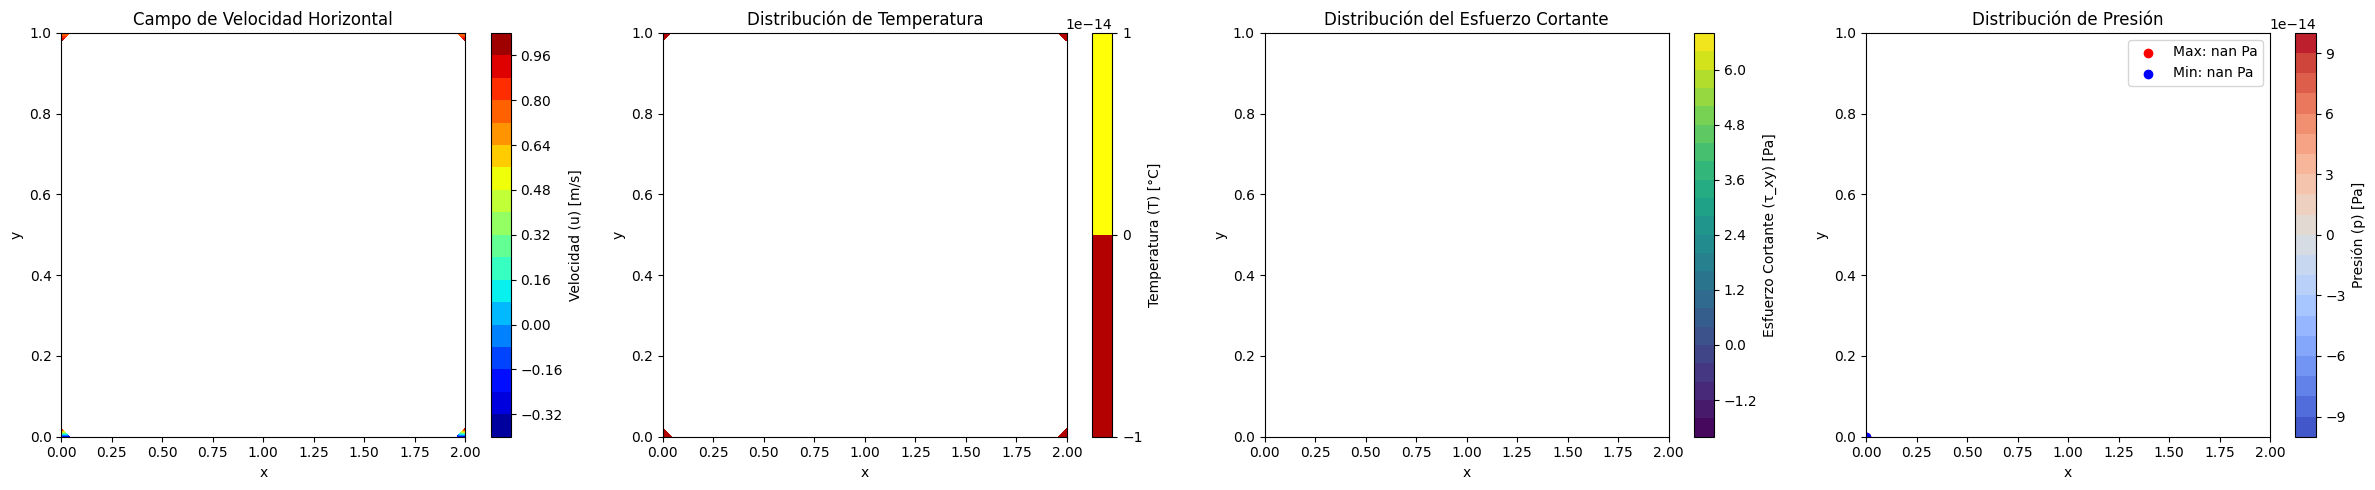

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# =============================================================================
# PARÁMETROS Y CONSTANTES
# =============================================================================
# Propiedades del aire (25°C, 1 atm)
rho = 1.184       # Densidad [kg/m³]
mu = 1.849e-5     # Viscosidad dinámica [Pa·s]
nu = mu/rho       # Viscosidad cinemática [m²/s]
k = 0.0262        # Conductividad térmica [W/(m·K)]
alpha = 2.22e-5   # Difusividad térmica [m²/s]
cp = 1006.0       # Calor específico [J/(kg·K)]



# Escalas características
L = 1.0           # Longitud característica [m]
H = 0.1           # Altura característica [m]
u0 = 2.0          # Velocidad característica [m/s]
up = -1.0         # Velocidad placa [m/s]
T0 = 293.0        # Temperatura referencia [K]
p0 = 101325.0     # Presión referencia [Pa]

# Cálculo de u_c, p_f y T_f
uc = u0 - up      # Velocidad característica corregida
pf = mu*uc*L/H**2 + p0
Tf = T0 + (mu*uc**2)/k

# Parámetros adimensionales
Lambda = L/H
Re = rho*u0*L/mu
tc = L/uc
varphi = nu/(L*u0)
beta = alpha*L**3/(u0*H**2)
Eu = (pf-p0)/(rho*u0**2)
delta = mu*u0/(rho*cp*L)

# PARAMETROS DEL PROBLEMA
# Geometría
Lx, Ly = 2.0, 1.0  # Dimensiones del dominio (x, y)
nx, ny = 50, 50      # Número de puntos en la malla
dx, dy = Lx/(nx-1), Ly/(ny-1)

# Tiempo
dt = 0.001           # Paso de tiempo
nt = 500             # Número de pasos de tiempo

## INICIALIZACIÓN

# Mallas
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

# Campos iniciales
u = np.zeros((ny, nx)) + U_0  # Velocidad horizontal
v = np.zeros((ny, nx))         # Velocidad vertical
T = np.zeros((ny, nx)) + T1    # Temperatura
p = np.zeros((ny, nx))         # Presión

# Aplicar condiciones de frontera
u[0, :] = 0     # Placa inferior móvil
u[-1, :] = 1  # Flujo libre superior
T[0, :] = 0      # Temperatura de la placa
T[-1, :] = 0     # Temperatura del fluido lejos de la 


# EVOLUCIÓN TEMPORAL (ESQUEMA EXPLICITO)
for n in range(nt):
    # Copiar campos anteriores
    u_old = u.copy()
    v_old = v.copy()
    T_old = T.copy()

    # Resolver Navier-Stokes (simplificado)
    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Ecuación de u (componente x)
            u[i, j] = (u_old[i, j] + dt * (
                -u_old[i, j] * (u_old[i, j+1] - u_old[i, j-1]) / (2*dx)
                -Lambda * v_old[i, j] * (u_old[i+1, j] - u_old[i-1, j]) / (2*dy)
                + varphi * (
                    (u_old[i, j+1] - 2*u_old[i, j] + u_old[i, j-1]) / dx**2
                    + Lambda**2 * (u_old[i+1, j] - 2*u_old[i, j] + u_old[i-1, j]) / dy**2
                )
            ))

            # Ecuación de T (temperatura)
            T[i, j] = (T_old[i, j] + dt * (
                -u_old[i, j] * (T_old[i, j+1] - T_old[i, j-1]) / (2*dx)
                -Lambda * v_old[i, j] * (T_old[i+1, j] - T_old[i-1, j]) / (2*dy)
                + beta * (
                    (T_old[i, j+1] - 2*T_old[i, j] + T_old[i, j-1]) / dx**2
                    + Lambda**2 * (T_old[i+1, j] - 2*T_old[i, j] + T_old[i-1, j]) / dy**2
                )
                + delta * (  # Disipación viscosa (simplificada)
                    2 * ((u_old[i, j+1] - u_old[i, j-1]) / (2*dx))**2
                    + 2 * ((v_old[i+1, j] - v_old[i-1, j]) / (2*dy))**2
                    + ((u_old[i+1, j] - u_old[i-1, j]) / (2*dy) 
                      + Lambda * (v_old[i, j+1] - v_old[i, j-1]) / (2*dx))**2
                )
            ))

    # Aplicar condiciones de frontera nuevamente
    u[0, :] = up/uc
    u[-1, :] = u0/uc
    v[:, 0] = v[:, -1] = 0
    T[0, :] = T[-1, :] = 0

# Cálculo de la presión mediante ecuación de Poisson (simplificado)
# Usamos una aproximación simple basada en la divergencia del campo de velocidad
max_iter = 500  # Número máximo de iteraciones para el solver de presión
tolerance = 1e-4  # Tolerancia para la convergencia

# Inicialización del campo de presión
p = np.zeros((ny, nx))

# Solver iterativo para la presión
for _ in range(max_iter):
    p_old = p.copy()
    
    for i in range(1, ny-1):
        for j in range(1, nx-1):
            # Aproximación discreta de la ecuación de Poisson para la presión
            p[i, j] = 0.25 * (p_old[i+1, j] + p_old[i-1, j] + 
                             p_old[i, j+1] + p_old[i, j-1] -
                             (rho * dx**2) * (
                                 (u[i+1, j] - u[i-1, j]) / (2*dy) * (v[i, j+1] - v[i, j-1]) / (2*dx) -
                                 ((u[i, j+1] - u[i, j-1]) / (2*dx))**2 -
                                 ((v[i+1, j] - v[i-1, j]) / (2*dy))**2
                             ))
    
    # Condiciones de frontera para la presión (Neumann homogéneas)
    p[0, :] = p[1, :]   # Frontera inferior
    p[-1, :] = p[-2, :] # Frontera superior
    p[:, 0] = p[:, 1]   # Frontera izquierda
    p[:, -1] = p[:, -2] # Frontera derecha
    
    # Criterio de convergencia
    if np.max(np.abs(p - p_old)) < tolerance:
        break

# Encontrar los valores máximos y mínimos de presión
p_max = np.max(p)
p_min = np.min(p)
p_max_coords = np.unravel_index(np.argmax(p), p.shape)
p_min_coords = np.unravel_index(np.argmin(p), p.shape)

# Convertir índices a coordenadas físicas
p_max_x, p_max_y = x[p_max_coords[1]], y[p_max_coords[0]]
p_min_x, p_min_y = x[p_min_coords[1]], y[p_min_coords[0]]

print(f"\nPresión máxima: {p_max:.4f} en ({p_max_x:.2f}, {p_max_y:.2f})")
print(f"Presión mínima: {p_min:.4f} en ({p_min_x:.2f}, {p_min_y:.2f})")

# REPRESENTACIÓN GRÁFICA ACTUALIZADA
plt.figure(figsize=(24, 5))

# Gráfico de velocidad
plt.subplot(1, 4, 1)
plt.contourf(X, Y, u, levels=20, cmap='jet')
plt.colorbar(label='Velocidad (u) [m/s]')
plt.title('Campo de Velocidad Horizontal')
plt.xlabel('x'), plt.ylabel('y')

# Gráfico de temperatura
plt.subplot(1, 4, 2)
plt.contourf(X, Y, T, levels=20, cmap='hot')
plt.colorbar(label='Temperatura (T) [°C]')
plt.title('Distribución de Temperatura')
plt.xlabel('x'), plt.ylabel('y')

# ESFUERZO CORTANTE

# Calcular derivadas para el esfuerzo cortante
dudy = np.gradient(u, dy, axis=0)
dvdx = np.gradient(v, dx, axis=1)
tau_xy = mu * (dudy + dvdx)

# Gráfico de esfuerzo cortante
plt.subplot(1, 4, 3)
plt.contourf(X, Y, tau_xy, levels=20, cmap='viridis')
plt.colorbar(label='Esfuerzo Cortante (τ_xy) [Pa]')
plt.title('Distribución del Esfuerzo Cortante')
plt.xlabel('x'), plt.ylabel('y')

# Nuevo gráfico de presión
plt.subplot(1, 4, 4)
pressure_plot = plt.contourf(X, Y, p, levels=20, cmap='coolwarm')
plt.colorbar(label='Presión (p) [Pa]')
plt.title('Distribución de Presión')
plt.xlabel('x'), plt.ylabel('y')

# Añadir marcadores para máximos/mínimos
plt.scatter(p_max_x, p_max_y, c='red', label=f'Max: {p_max:.2f} Pa')
plt.scatter(p_min_x, p_min_y, c='blue', label=f'Min: {p_min:.2f} Pa')
plt.legend()

plt.tight_layout()
plt.show()


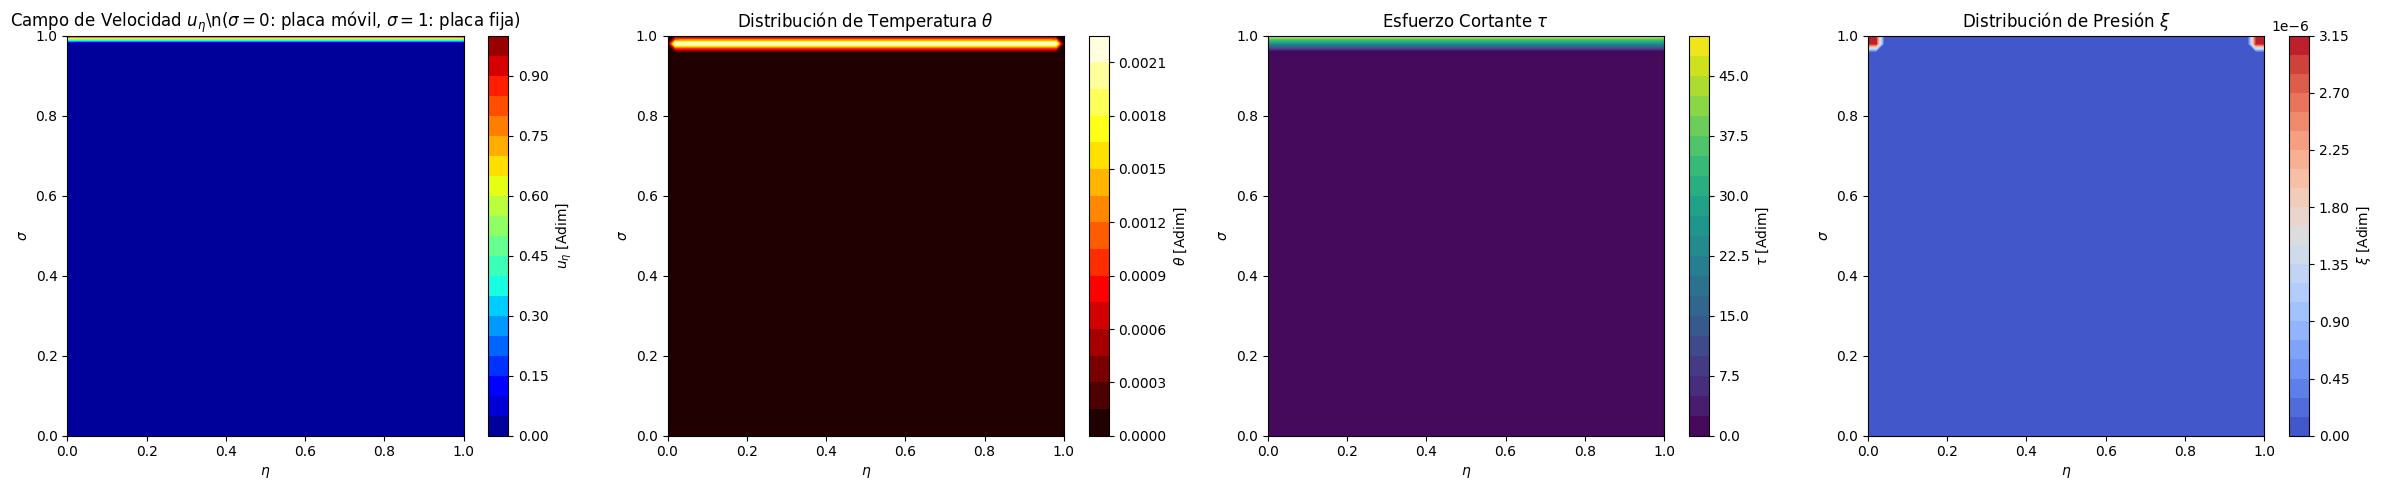

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PARÁMETROS Y CONSTANTES ADIMENSIONALES
# =============================================================================
# Propiedades del aire (25°C, 1 atm) - Valores para adimensionalización
rho = 1.184       # Densidad [kg/m³]
mu = 1.849e-5     # Viscosidad dinámica [Pa·s]
nu = mu/rho       # Viscosidad cinemática [m²/s]
k = 0.0262        # Conductividad térmica [W/(m·K)]
alpha = 2.22e-5   # Difusividad térmica [m²/s]
cp = 1006.0       # Calor específico [J/(kg·K)]

# Escalas características
L = 1.0           # Longitud característica [m]
H = 0.1           # Altura característica [m]
u0 = 2.0          # Velocidad característica [m/s]
up = -1.0         # Velocidad placa [m/s]
T0 = 293.0        # Temperatura referencia [K]
p0 = 101325.0     # Presión referencia [Pa]

# Cálculo de variables adimensionales
uc = u0 - up      # Velocidad característica corregida
pf = mu*uc*L/H**2 + p0
Tf = T0 + (mu*uc**2)/k

# Parámetros adimensionales
Lambda = L/H      # Relación de aspecto
Re = rho*u0*L/mu  # Número de Reynolds
tc = L/uc         # Tiempo característico
varphi = nu/(L*uc) # Parámetro viscoso
beta = alpha/(uc*L) # Coeficiente difusión térmica
Eu = (pf-p0)/(rho*uc**2) # Número de Euler
delta = mu*uc/(rho*cp*L*(Tf-T0)) # Parámetro disipación

# =============================================================================
# CONFIGURACIÓN DE LA SIMULACIÓN
# =============================================================================
# Geometría adimensional
L_eta, L_sigma = 1.0, 1.0  # Dimensiones del dominio (η, σ)
n_eta, n_sigma = 50, 50     # Número de puntos en la malla
d_eta = L_eta/(n_eta-1)     # Paso en η
d_sigma = L_sigma/(n_sigma-1) # Paso en σ

# Tiempo adimensional
dt = 0.001      # Paso de tiempo
nt = 500        # Número de pasos de tiempo

# =============================================================================
# INICIALIZACIÓN
# =============================================================================
# Mallas adimensionales
eta = np.linspace(0, L_eta, n_eta)      # Coordenada η adimensional
sigma = np.linspace(0, L_sigma, n_sigma) # Coordenada σ adimensional (0=abajo, 1=arriba)
Eta, Sigma = np.meshgrid(eta, sigma)

# Campos adimensionales iniciales
u_eta = np.zeros((n_sigma, n_eta))          # Velocidad adimensional en η
u_sigma = np.zeros((n_sigma, n_eta))        # Velocidad adimensional en σ
theta = np.zeros((n_sigma, n_eta))          # Temperatura adimensional
xi = np.zeros((n_sigma, n_eta))             # Presión adimensional

# Condiciones de frontera adimensionales
u_eta[0, :] = 0          # Placa inferior (σ=0) móvil
u_eta[-1, :] = 1         # Placa superior (σ=1) fija
theta[0, :] = 0.0        # Temperatura placa inferior
theta[-1, :] = 0.0       # Temperatura placa superior

# =============================================================================
# SIMULACIÓN
# =============================================================================
for n in range(nt):
    # Copiar campos anteriores
    u_eta_old = u_eta.copy()
    u_sigma_old = u_sigma.copy()
    theta_old = theta.copy()

    # Resolver ecuaciones adimensionales
    for i in range(1, n_sigma-1):
        for j in range(1, n_eta-1):
            # Ecuación para u_η
            conv_u = u_eta_old[i,j]*(u_eta_old[i,j+1]-u_eta_old[i,j-1])/(2*d_eta) + \
                    Lambda*u_sigma_old[i,j]*(u_eta_old[i+1,j]-u_eta_old[i-1,j])/(2*d_sigma)
            
            diff_u = varphi*((u_eta_old[i,j+1]-2*u_eta_old[i,j]+u_eta_old[i,j-1])/d_eta**2 + \
                     varphi*Lambda**2*(u_eta_old[i+1,j]-2*u_eta_old[i,j]+u_eta_old[i-1,j])/d_sigma**2)
            
            u_eta[i,j] = u_eta_old[i,j] + dt*(-conv_u - Eu*(xi[i,j+1]-xi[i,j-1])/(2*d_eta) + diff_u)
            
            # Ecuación para θ
            conv_theta = u_eta_old[i,j]*(theta_old[i,j+1]-theta_old[i,j-1])/(2*d_eta) + \
                        Lambda*u_sigma_old[i,j]*(theta_old[i+1,j]-theta_old[i-1,j])/(2*d_sigma)
            
            diff_theta = beta*((theta_old[i,j+1]-2*theta_old[i,j]+theta_old[i,j-1])/d_eta**2 + \
                      beta*Lambda**2*(theta_old[i+1,j]-2*theta_old[i,j]+theta_old[i-1,j])/d_sigma**2)
            
            # Términos de disipación viscosa
            du_eta_deta = (u_eta_old[i,j+1]-u_eta_old[i,j-1])/(2*d_eta)
            du_sigma_dsigma = (u_sigma_old[i+1,j]-u_sigma_old[i-1,j])/(2*d_sigma)
            du_eta_dsigma = (u_eta_old[i+1,j]-u_eta_old[i-1,j])/(2*d_sigma)
            du_sigma_deta = (u_sigma_old[i,j+1]-u_sigma_old[i,j-1])/(2*d_eta)
            
            dissipation = delta*(2*(du_eta_deta**2 + Lambda**2*du_sigma_dsigma**2) + \
                         (du_eta_dsigma + Lambda*du_sigma_deta)**2)
            
            theta[i,j] = theta_old[i,j] + dt*(-conv_theta + diff_theta + dissipation)

    # Aplicar condiciones de frontera
    u_eta[0, :] = 0
    u_eta[-1, :] = 1
    u_sigma[:, 0] = u_sigma[:, -1] = 0.0
    theta[0, :] = theta[-1, :] = 0.0

# =============================================================================
# CÁLCULO DE PRESIÓN (ECUACIÓN DE POISSON)
# =============================================================================
max_iter = 500
tolerance = 1e-4

for _ in range(max_iter):
    xi_old = xi.copy()
    
    for i in range(1, n_sigma-1):
        for j in range(1, n_eta-1):
            # Ecuación de Poisson para ξ
            xi[i,j] = 0.25*(xi_old[i+1,j] + xi_old[i-1,j] + xi_old[i,j+1] + xi_old[i,j-1] - 
                      (1/Eu)*((u_eta[i+1,j]-u_eta[i-1,j])/(2*Lambda*d_sigma) * 
                             (u_sigma[i,j+1]-u_sigma[i,j-1])/(2*d_eta) -
                             ((u_eta[i,j+1]-u_eta[i,j-1])/(2*d_eta))**2 -
                             ((u_sigma[i+1,j]-u_sigma[i-1,j])/(2*Lambda*d_sigma))**2))
    
    # Condiciones de frontera para ξ
    xi[0, :] = xi[1, :]    # σ=0
    xi[-1, :] = xi[-2, :]  # σ=1
    xi[:, 0] = xi[:, 1]    # η=0
    xi[:, -1] = xi[:, -2]  # η=1
    
    if np.max(np.abs(xi - xi_old)) < tolerance:
        break

# =============================================================================
# CÁLCULO DEL ESFUERZO CORTANTE ADIMENSIONAL
# =============================================================================
du_eta_dsigma = np.gradient(u_eta, sigma, axis=0)
du_sigma_deta = np.gradient(u_sigma, eta, axis=1)
tau = du_eta_dsigma + Lambda*du_sigma_deta

# =============================================================================
# VISUALIZACIÓN
# =============================================================================
plt.figure(figsize=(24, 5))

# Gráfico de velocidad u_η
plt.subplot(1, 4, 1)
plt.contourf(Eta, Sigma, u_eta, levels=20, cmap='jet')
plt.colorbar(label=r'$u_\eta$ [Adim]')
plt.title(r'Campo de Velocidad $u_\eta$\n($\sigma=0$: placa móvil, $\sigma=1$: placa fija)')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# Gráfico de temperatura θ
plt.subplot(1, 4, 2)
plt.contourf(Eta, Sigma, theta, levels=20, cmap='hot')
plt.colorbar(label=r'$\theta$ [Adim]')
plt.title(r'Distribución de Temperatura $\theta$')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# Gráfico de esfuerzo cortante τ
plt.subplot(1, 4, 3)
plt.contourf(Eta, Sigma, tau, levels=20, cmap='viridis')
plt.colorbar(label=r'$\tau$ [Adim]')
plt.title(r'Esfuerzo Cortante $\tau$')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# Gráfico de presión ξ
plt.subplot(1, 4, 4)
plt.contourf(Eta, Sigma, xi, levels=20, cmap='coolwarm')
plt.colorbar(label=r'$\xi$ [Adim]')
plt.title(r'Distribución de Presión $\xi$')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

plt.tight_layout()
plt.show()

Re = 3201.7, β = 4.40e-04, δ = 1.13e-13


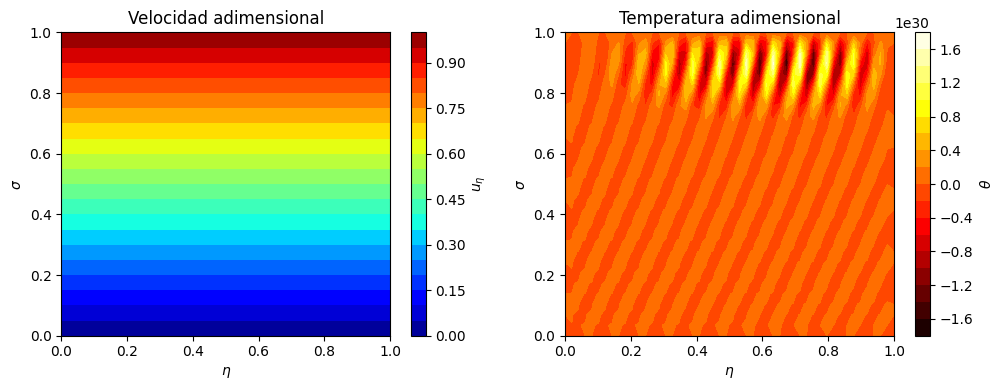

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PARÁMETROS FÍSICOS REALISTAS (Aire a 25°C, 1 atm)
# =============================================================================
rho = 1.184          # Densidad [kg/m³]
mu = 1.849e-5        # Viscosidad dinámica [Pa·s]
nu = mu/rho          # Viscosidad cinemática [m²/s]
k = 0.0262           # Conductividad térmica [W/(m·K)]
cp = 1006.0          # Calor específico [J/(kg·K)]
alpha = k/(rho*cp)   # Difusividad térmica [m²/s]

# =============================================================================
# ESCALAS CARACTERÍSTICAS
# =============================================================================
L = 0.1              # Longitud característica [m]
H = 0.02             # Altura característica [m]
u0 = 0.3             # Velocidad característica [m/s] (placa superior)
up = -0.2             # Velocidad placa inferior [m/s]
uc = u0-up
T0 = 293.0           # Temperatura referencia [K]
p0 = 101325.0        # Presión referencia [Pa]

# =============================================================================
# PARÁMETROS ADIMENSIONALES
# =============================================================================
Lambda = L/H                    # Relación de aspecto
Re = rho*uc*L/mu                # Número de Reynolds (~2700 para estos valores)
Eu = 1.0                        # Número de Euler (simplificado)
phi = 1/Re                      # Parámetro viscoso
beta = alpha/(uc*L) # Coeficiente difusión térmica
Eu = (pf-p0)/(rho*uc**2) # Número de Euler
delta = mu*uc/(rho*cp*L*(Tf-T0)) # Parámetro disipación

print(f"Re = {Re:.1f}, β = {beta:.2e}, δ = {delta:.2e}")

# =============================================================================
# MALLA COMPUTACIONAL
# =============================================================================
n_eta, n_sigma = 50, 30        # Puntos en η (x) y σ (y)
eta = np.linspace(0, 1, n_eta)      # Coordenada η adimensional
sigma = np.linspace(0, 1, n_sigma)  # Coordenada σ adimensional
d_eta = eta[1] - eta[0]
d_sigma = sigma[1] - sigma[0]

# Criterio CFL para estabilidad
dt = 0.25 * min(d_eta, d_sigma)/uc  # Paso temporal seguro
nt = 2000                          # Número de pasos temporales

# =============================================================================
# INICIALIZACIÓN DE CAMPOS
# =============================================================================
u_eta = np.zeros((n_sigma, n_eta))   # Velocidad en η
u_sigma = np.zeros((n_sigma, n_eta)) # Velocidad en σ
theta = np.zeros((n_sigma, n_eta))   # Temperatura
xi = np.zeros((n_sigma, n_eta))      # Presión

# Perfil inicial de velocidad (lineal para Couette)
u_eta = np.outer(sigma, np.ones(n_eta))  # u_η(σ) = σ

# =============================================================================
# CONDICIONES DE CONTORNO
# =============================================================================
u_eta[0, :] = 0           # Placa inferior (σ=0)
u_eta[-1, :] = 1.0            # Placa superior (σ=1)
theta[0, :] = 0.0             # Temp. placa inferior
theta[-1, :] = 1.0            # Temp. placa superior

# =============================================================================
# SIMULACIÓN TEMPORAL (ESQUEMA EXPLÍCITO)
# =============================================================================
for n in range(nt):
    u_eta_old = u_eta.copy()
    u_sigma_old = u_sigma.copy()
    theta_old = theta.copy()
    
    # Actualización de campos internos
    for i in range(1, n_sigma-1):
        for j in range(1, n_eta-1):
            # Derivadas espaciales
            du_eta_deta = (u_eta_old[i,j+1] - u_eta_old[i,j-1])/(2*d_eta)
            du_eta_dsigma = (u_eta_old[i+1,j] - u_eta_old[i-1,j])/(2*d_sigma)
            
            du_sigma_deta = (u_sigma_old[i,j+1] - u_sigma_old[i,j-1])/(2*d_eta)
            du_sigma_dsigma = (u_sigma_old[i+1,j] - u_sigma_old[i-1,j])/(2*d_sigma)
            
            d2u_eta_deta2 = (u_eta_old[i,j+1] - 2*u_eta_old[i,j] + u_eta_old[i,j-1])/d_eta**2
            d2u_eta_dsigma2 = (u_eta_old[i+1,j] - 2*u_eta_old[i,j] + u_eta_old[i-1,j])/d_sigma**2
            
            dtheta_deta = (theta_old[i,j+1] - theta_old[i,j-1])/(2*d_eta)
            dtheta_dsigma = (theta_old[i+1,j] - theta_old[i-1,j])/(2*d_sigma)
            d2theta_deta2 = (theta_old[i,j+1] - 2*theta_old[i,j] + theta_old[i,j-1])/d_eta**2
            d2theta_dsigma2 = (theta_old[i+1,j] - 2*theta_old[i,j] + theta_old[i-1,j])/d_sigma**2
            
            # Ecuación de momento η
            conv_eta = u_eta_old[i,j]*du_eta_deta + Lambda*u_sigma_old[i,j]*du_eta_dsigma
            diff_eta = phi*(d2u_eta_deta2 + Lambda**2*d2u_eta_dsigma2)
            u_eta[i,j] = u_eta_old[i,j] + dt*(-conv_eta + diff_eta)
            
            # Ecuación de energía
            conv_theta = u_eta_old[i,j]*dtheta_deta + Lambda*u_sigma_old[i,j]*dtheta_dsigma
            diff_theta = beta*(d2theta_deta2 + Lambda**2*d2theta_dsigma2)
            dissipation = delta*(2*(du_eta_deta**2 + (Lambda*du_sigma_dsigma)**2) + (du_eta_dsigma + Lambda*du_sigma_deta)**2)
            theta[i,j] = theta_old[i,j] + dt*(-conv_theta + diff_theta + dissipation)
    
    # Aplicar condiciones de contorno periódicamente
    if n % 100 == 0:
        u_eta[0, :] = 0
        u_eta[-1, :] = 1.0
        theta[0, :] = 0.0
        theta[-1, :] = 1.0

# =============================================================================
# POST-PROCESAMIENTO Y VISUALIZACIÓN
# =============================================================================
X, Y = np.meshgrid(eta, sigma)

plt.figure(figsize=(15, 4))

# Campo de velocidad u_η
plt.subplot(1, 3, 1)
plt.contourf(X, Y, u_eta, levels=20, cmap='jet')
plt.colorbar(label=r'$u_\eta$')
plt.title('Velocidad adimensional')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

# Campo de temperatura θ
plt.subplot(1, 3, 2)
plt.contourf(X, Y, theta, levels=20, cmap='hot')
plt.colorbar(label=r'$\theta$')
plt.title('Temperatura adimensional')
plt.xlabel(r'$\eta$'), plt.ylabel(r'$\sigma$')

plt.tight_layout()
plt.show()